In [1]:
# Import packages
from pathlib import Path

project_dir = Path("/home/mcaskey/10XvParse/")
species = "hsapiens"
index_dir = project_dir / "Index" / "human"
analysis_name = "Analysis_5"
analysis_dir = Path.cwd() 

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [5]:
def get_kb_dir(project_dir: Path, assay: str, type: str = None) -> Path:
    if type is None:
        kb_dir = project_dir / "Data" / analysis_name / assay / "kb_python" / "sampled_out"
    else:
        kb_dir = project_dir / "Data" / analysis_name / assay / "kb_python" / f"sampled_{type}_out"
    return kb_dir

In [6]:
data_10x = plotting.init_processing('10x', get_kb_dir(project_dir, '10x'), '10X Genomics')
data_polyT = plotting.init_processing('polyT', get_kb_dir(project_dir, 'parse', type = 'polyT'), "Parse 3\'")
data_randO = plotting.init_processing('randO', get_kb_dir(project_dir, 'parse', type = 'randO'), 'Parse Random Oligo')
data_parse = plotting.init_processing('parse', get_kb_dir(project_dir, 'parse'), "Parse", modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Population Upsampling Estimation

PreSeq output already exists for all datasets.


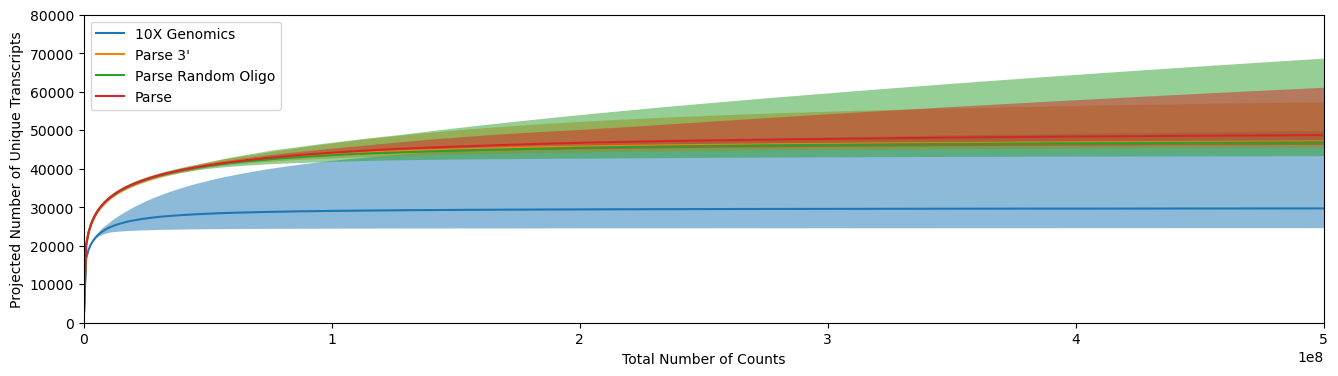

In [7]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
plotting.upsample(raw_datasets, Path("preseq"), overwrite=False)
plotting.plot_upsample(raw_datasets, Path("preseq"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

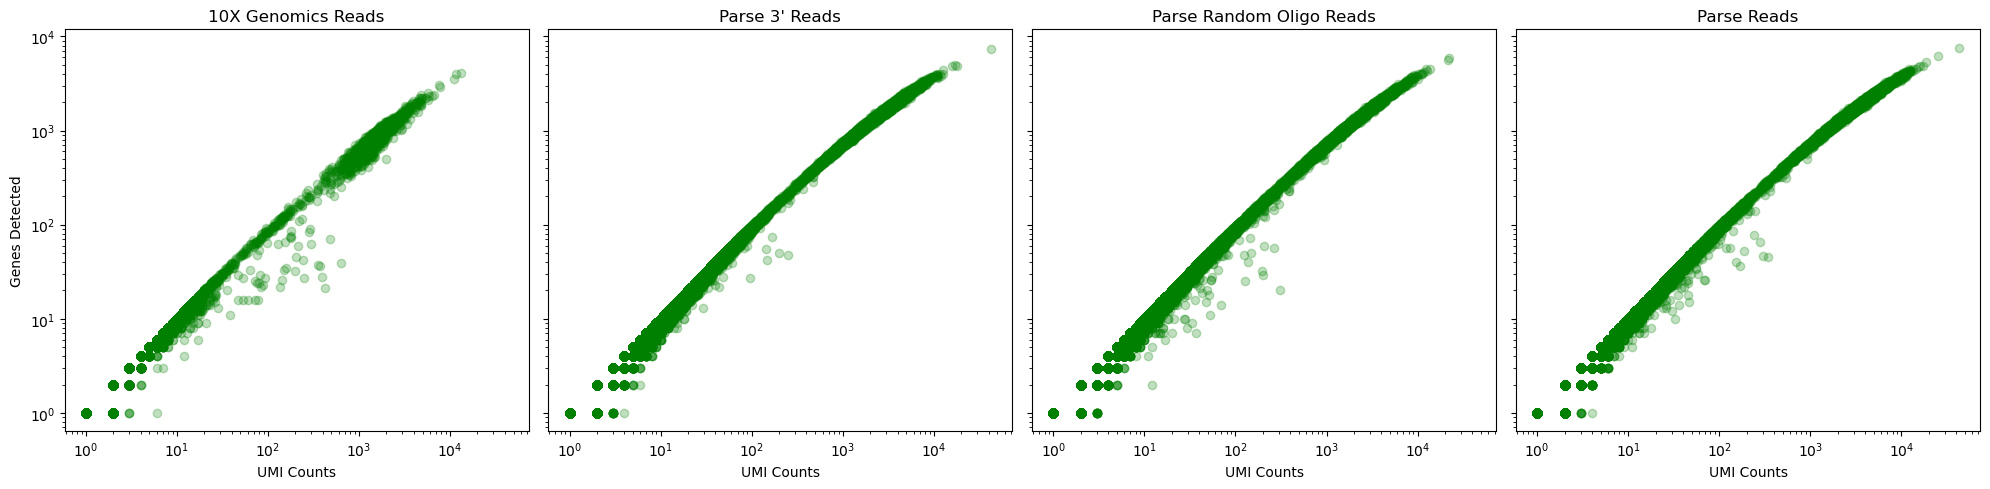

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True, sharex=True)

for i, data in enumerate(raw_datasets):
    plotting.scatter_reads(ax[i], data)

ax[0].set_ylabel("Genes Detected")

plt.tight_layout()
plt.show()

In [9]:
# Path to save gene metadata so don't need to query Ensembl 
# more than once
gene_info = plotting.query_ensembl(analysis_dir, index_dir=index_dir, overwrite=True) 

In [10]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


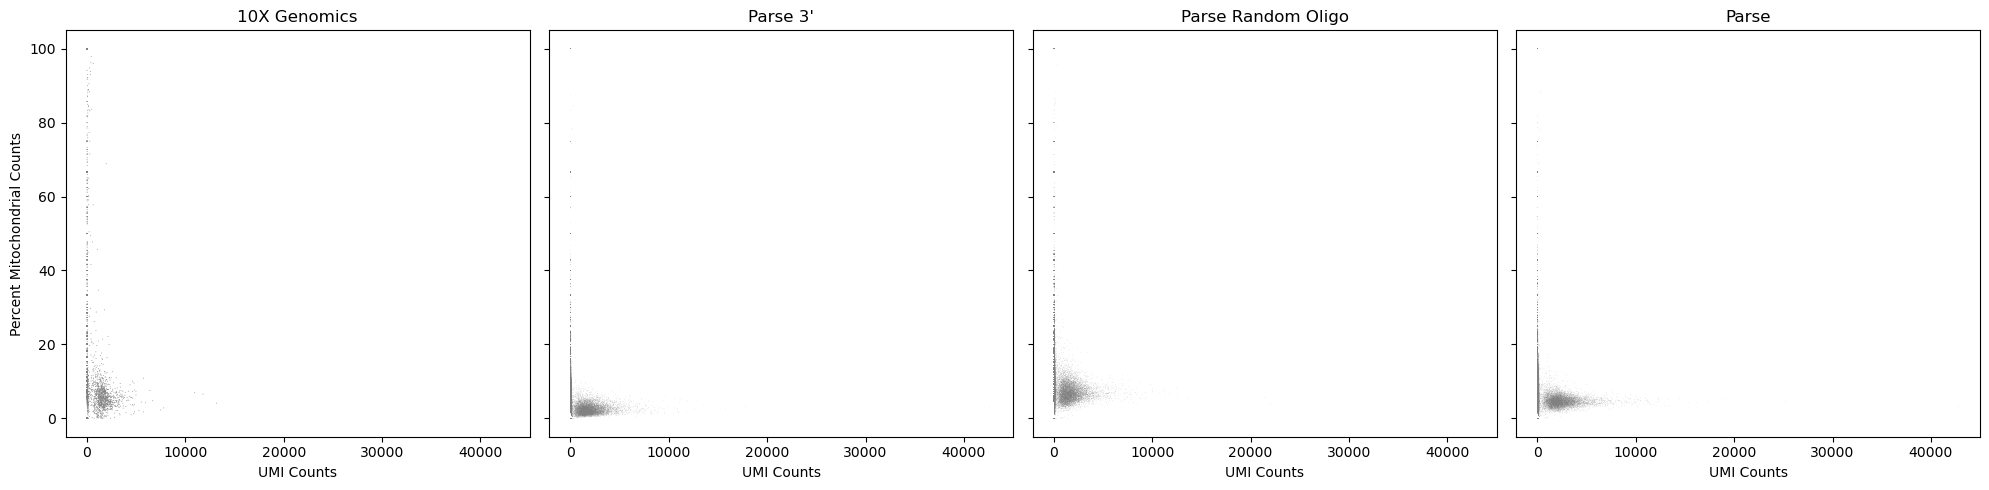

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True,sharex=True)
for i, data in enumerate(raw_datasets):
    plotting.mito_scatter(ax[i], data)

ax[0].set_ylabel("Percent Mitochondrial Counts")

plt.tight_layout()
plt.show()

1,180 cells passed the 75 UMI threshold for 10X Genomics
8,145 cells passed the 300 UMI threshold for Parse 3'


8,083 cells passed the 300 UMI threshold for Parse Random Oligo


8,192 cells passed the 300 UMI threshold for Parse


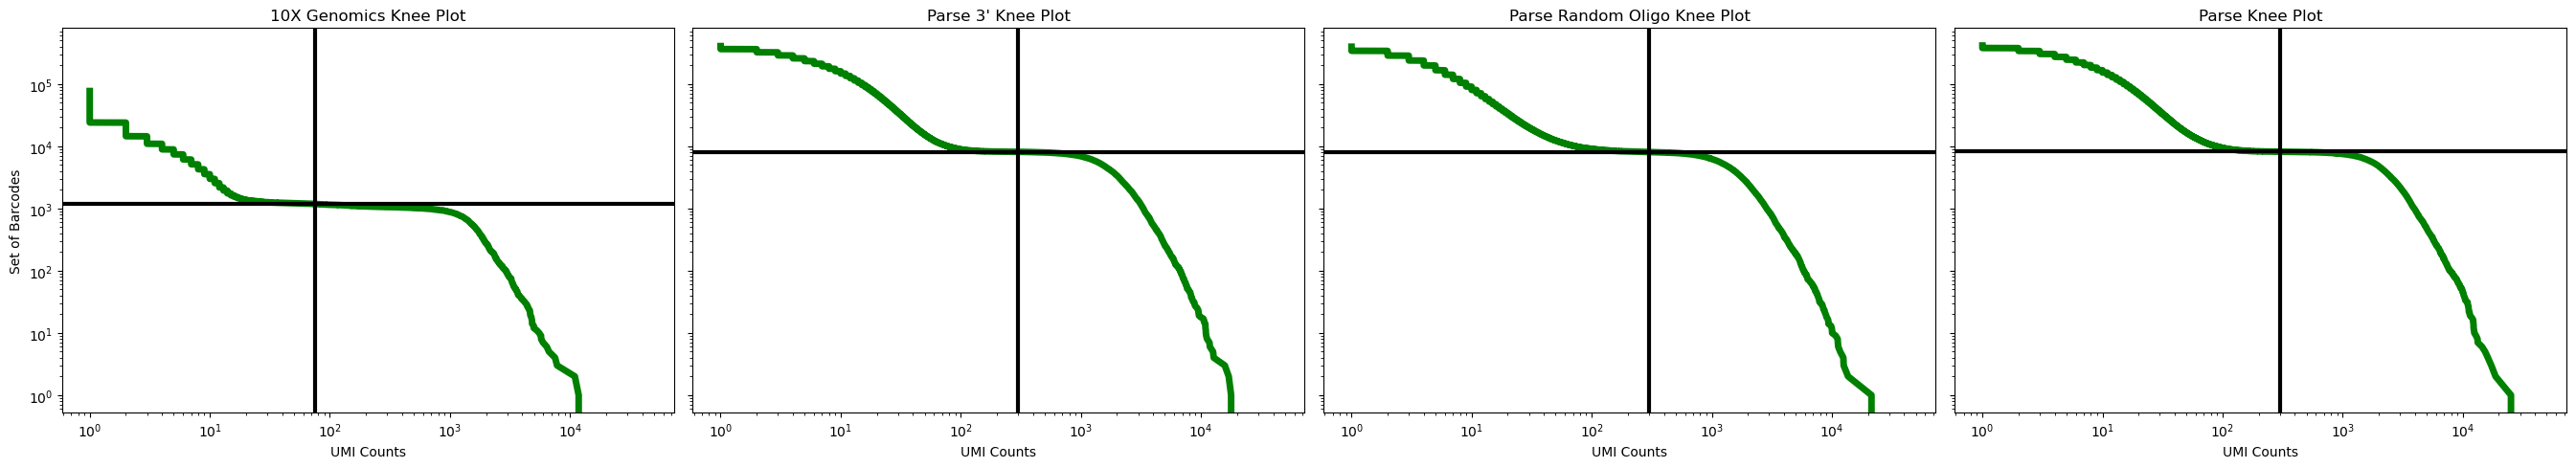

In [12]:
fig, ax = plt.subplots(1, 4, figsize=(27,5), sharey=True, sharex=True)

cutoffs = [75, 300, 300, 300]

datasets = []
for i, (data, cutoff) in enumerate(zip(raw_datasets, cutoffs)):
    datasets.append(plotting.knee_plot(ax[i], data, cutoff=cutoff))

ax[0].set_ylabel("Set of Barcodes")

plt.tight_layout()
plt.show()

In [13]:
full_gene_info_path = project_dir / analysis_dir 
gene_info = plotting.update_gene_info(gene_info, datasets, full_gene_info_path)

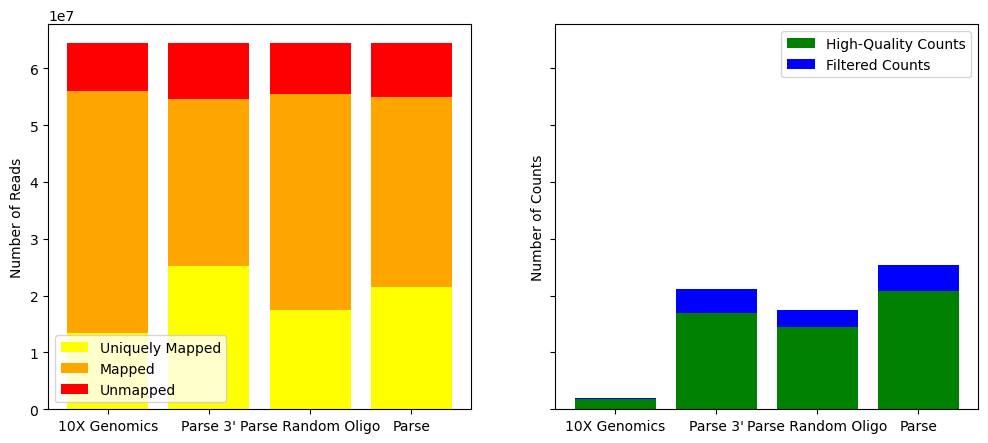

In [14]:
plotting.plot_filtering_metrics(datasets)

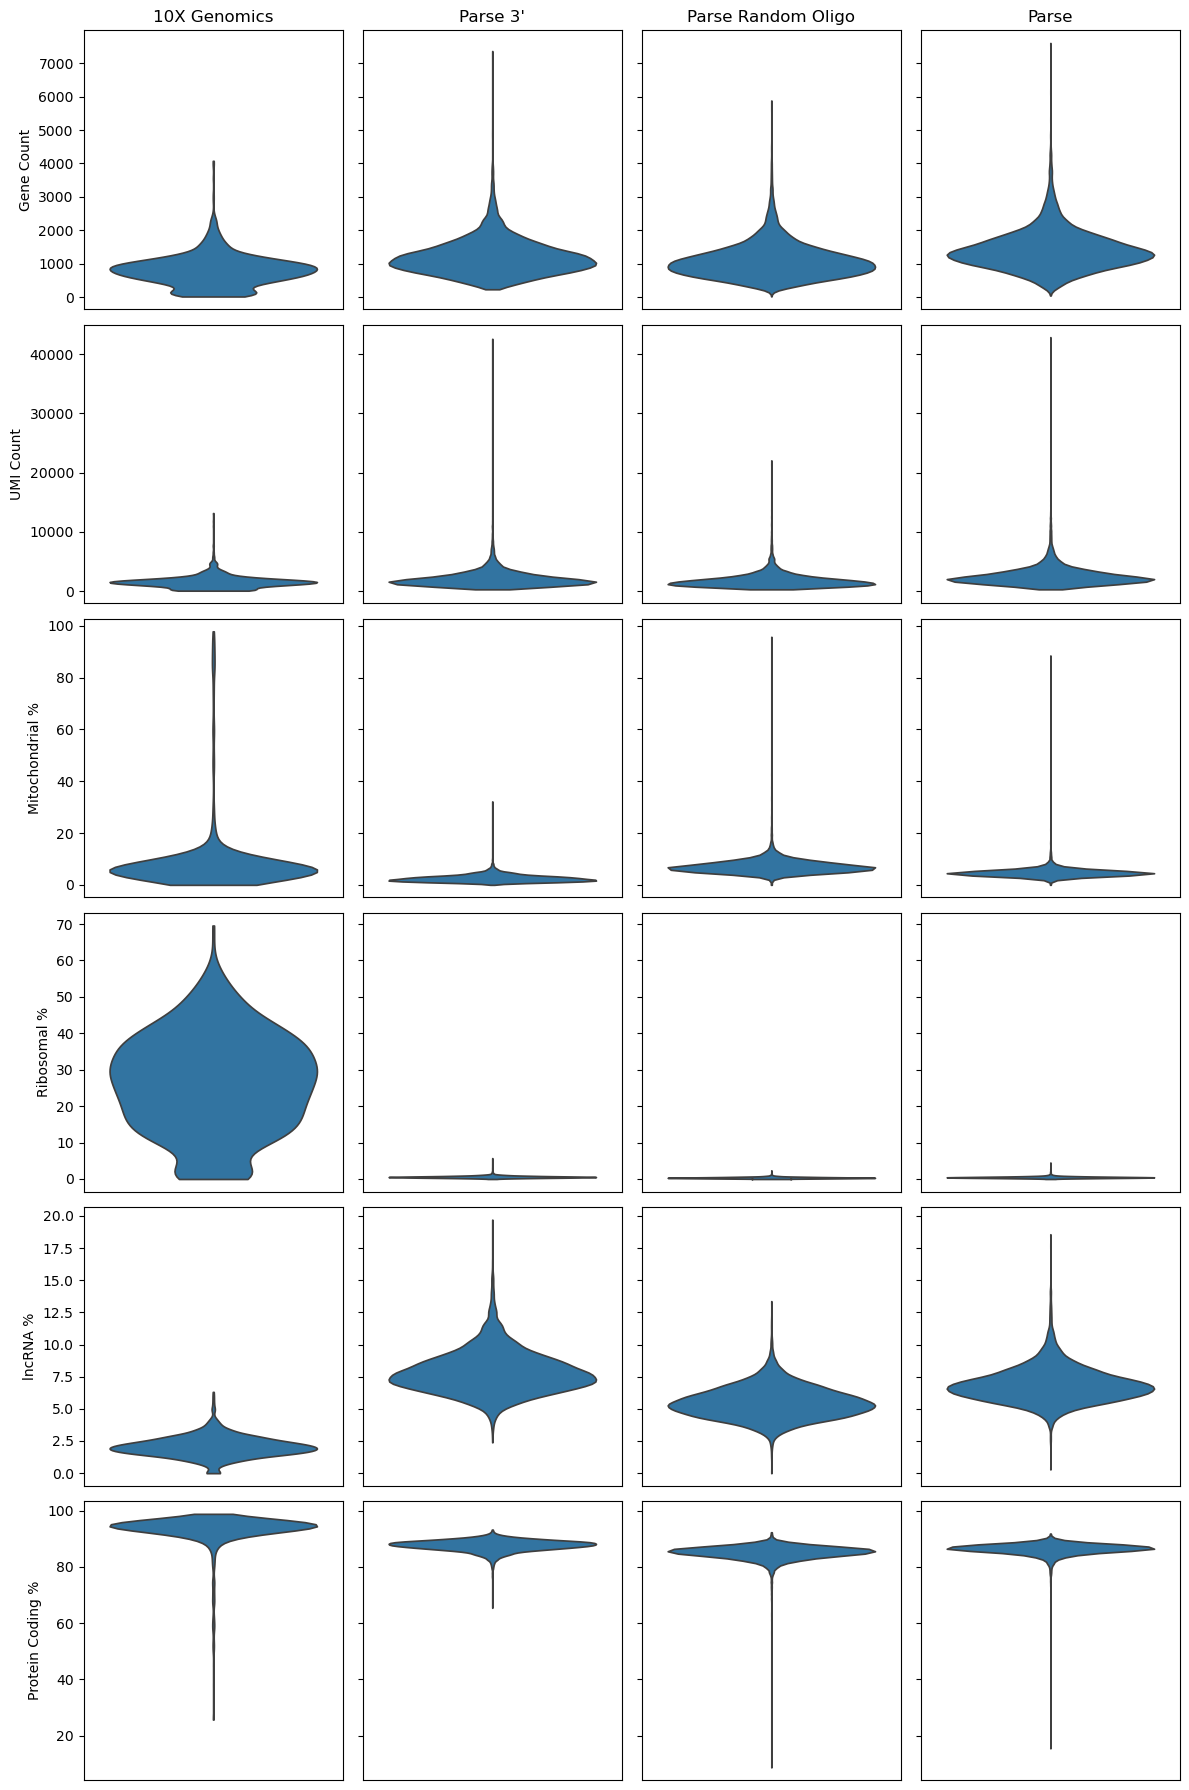

In [15]:
groups = ['n_genes', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Mitochondrial %', 'Ribosomal %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names, figsize=(12,18))

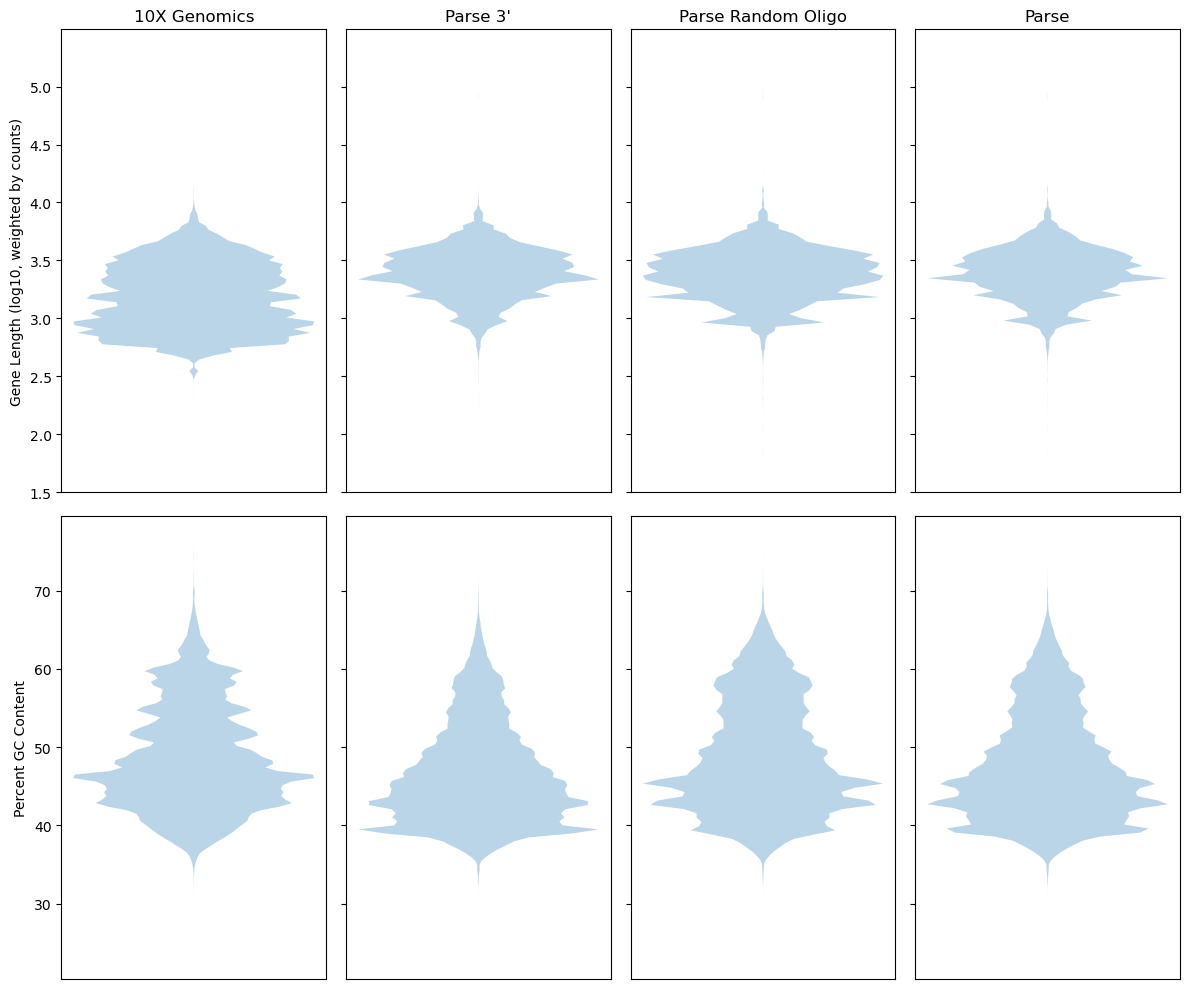

In [16]:
plotting.plot_gene_metrics(datasets, sample_size = 1000000)

# Doublet Detection Comparison

In [17]:
scrubs = plotting.detect_doublets(datasets)

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...


Calculating doublet scores...


Automatically set threshold at doublet score = 0.54
Detected doublet rate = 1.2%
Estimated detectable doublet fraction = 7.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 15.5%
Elapsed time: 4.5 seconds
Preprocessing...


Simulating doublets...


Embedding transcriptomes using PCA...


...

Preprocessing...


Simulating doublets...


Embedding transcriptomes using PCA...


Calculating doublet scores...


Automatically set threshold at doublet score = 0.30
Detected doublet rate = 8.4%
Estimated detectable doublet fraction = 50.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 16.6%
Elapsed time: 14.9 seconds


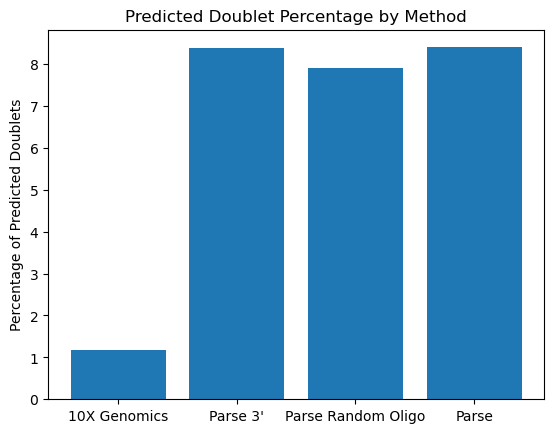

In [18]:
bottom = np.zeros(len(datasets))
titles = [data.uns['title'] for data in datasets]
percent_doublets = [data.obs['predicted_doublet'].sum()/len(data.obs)*100 for data in datasets]

plt.bar(titles, percent_doublets)
plt.ylabel('Percentage of Predicted Doublets')
plt.title('Predicted Doublet Percentage by Method')

plt.show()

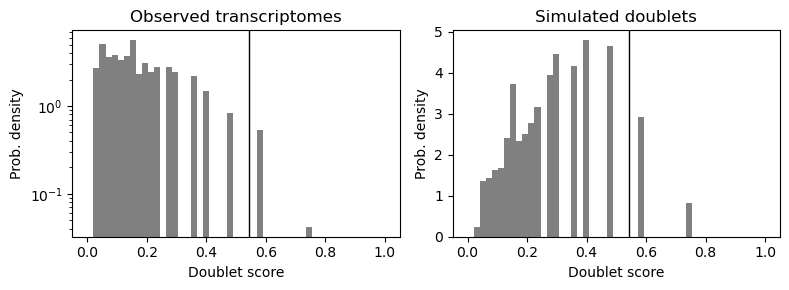

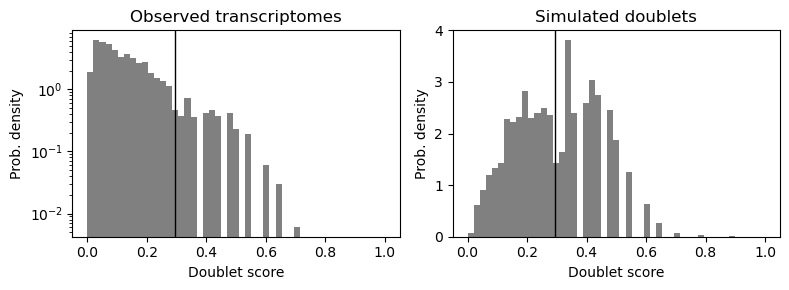

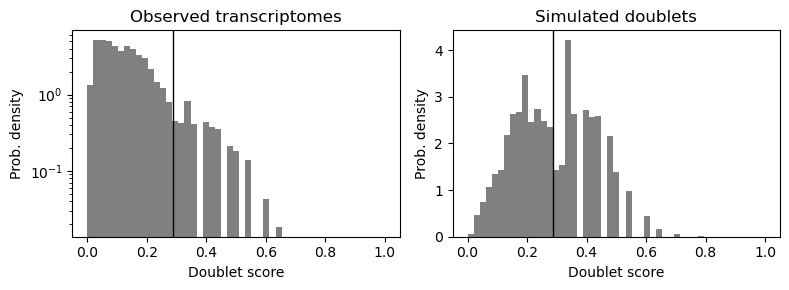

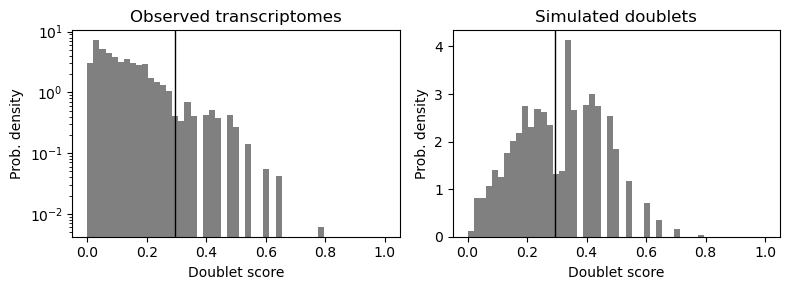

In [19]:
# Should see two peaks separated by threshold
for scrub in scrubs:
    scrub.plot_histogram()

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


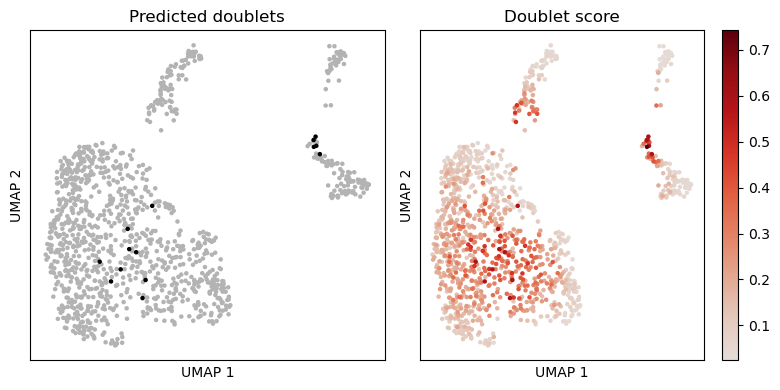

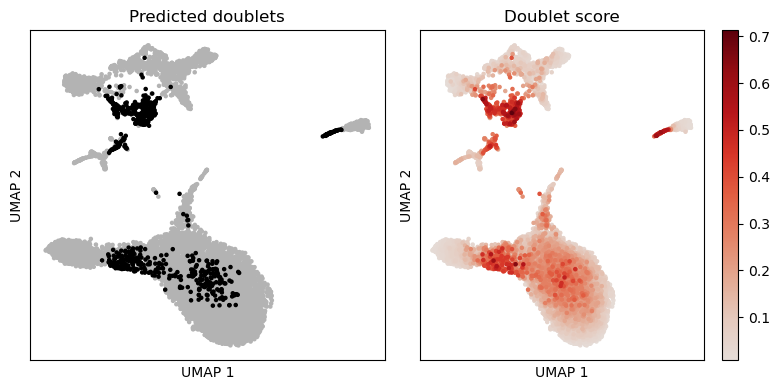

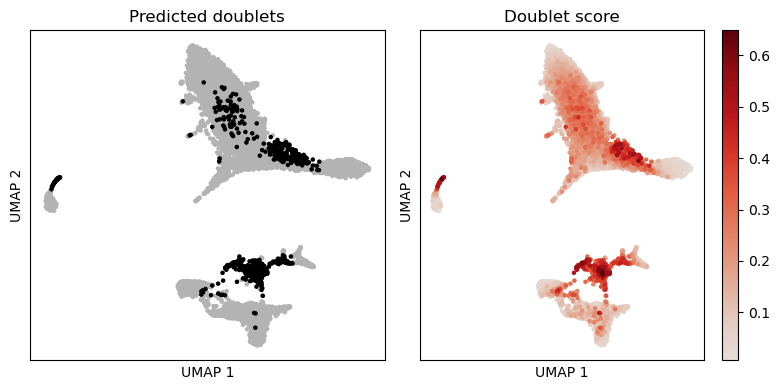

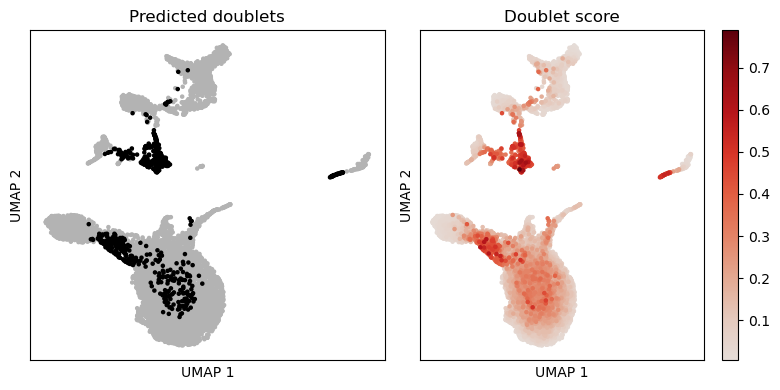

In [20]:
# Should see clustering of doublets
for scrub in scrubs:
    scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3)) 
    scrub.plot_embedding('UMAP', order_points=True)

# Read/Gene Comparisons

In [21]:
# Marker genes for PBMCs from www.biocompare.com
T_marker_names = ['CD3D', 'CD3G','CD3E', 'CD4', 'CD8A', 'CD8B']
T_markers = ['ENSG00000167286.12', 'ENSG00000160654.11', 
             'ENSG00000198851.10', 'ENSG00000010610.10', 
             'ENSG00000153563.17', 'ENSG00000172116.23']

B_marker_names = ['CD19', 'CD24', 'CD40', 'CD72']
B_markers = ['ENSG00000177455.15', 'ENSG00000272398.6'
             'ENSG00000101017.15', 'ENSG00000137101.14']

NK_marker_names = ['FCGR3A', 'FCGR3B', 'NCAM1']
NK_markers = ['ENSG00000203747.13', 'ENSG00000162747.13', 'ENSG00000149294.18']

monocyte_marker_names = ['CD14'] # and CD16
monocyte_markers = ['ENSG00000170458.15']

markers = T_markers + B_markers + NK_markers + monocyte_markers
marker_names = T_marker_names + B_marker_names + NK_marker_names + monocyte_marker_names

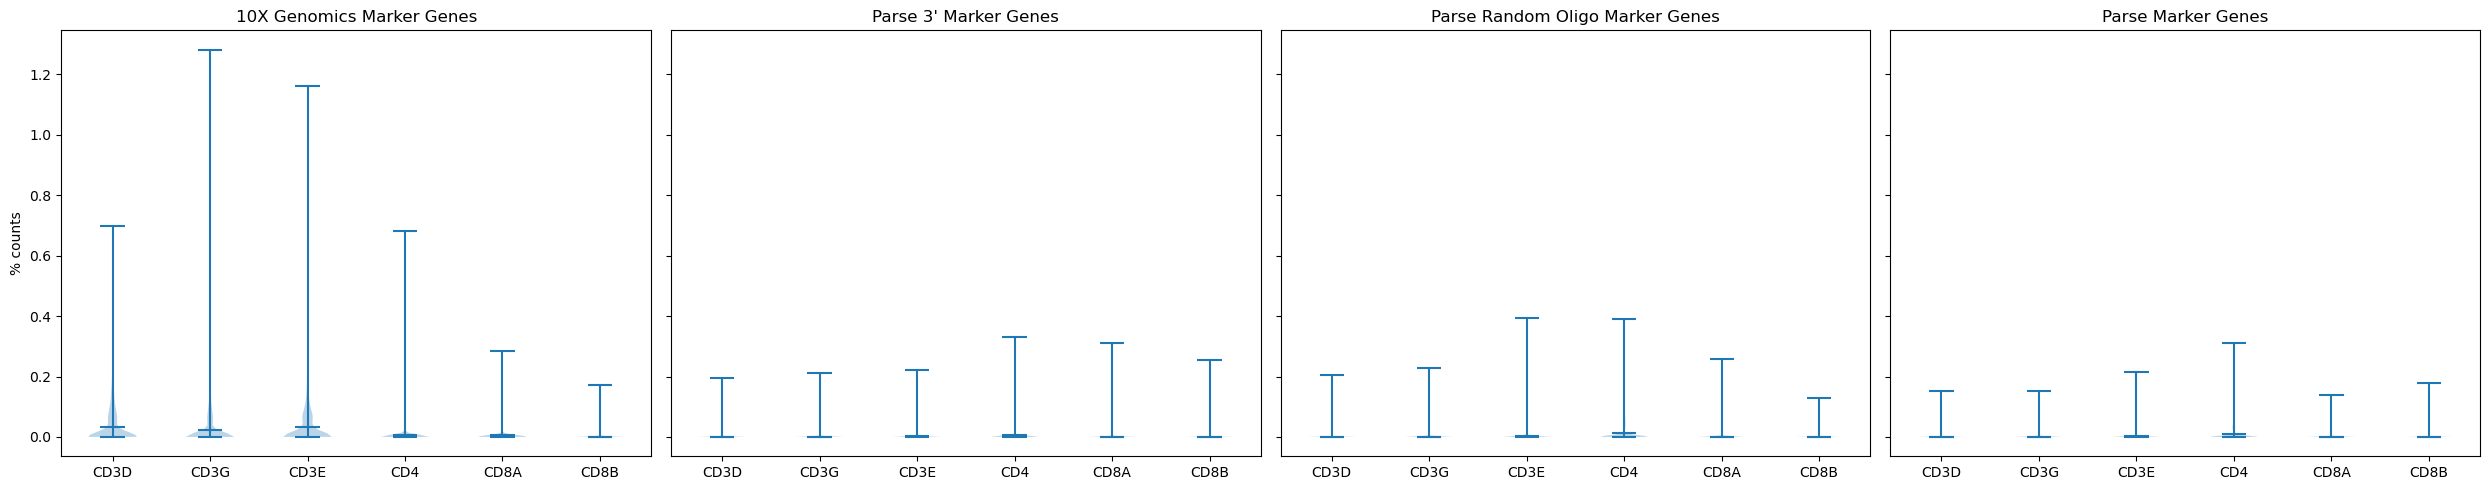

In [22]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)

for i, data in enumerate(datasets):
    plotting.marker_genes(ax[i], data, T_marker_names)

ax[0].set_ylabel("% counts")

plt.tight_layout()
plt.show()

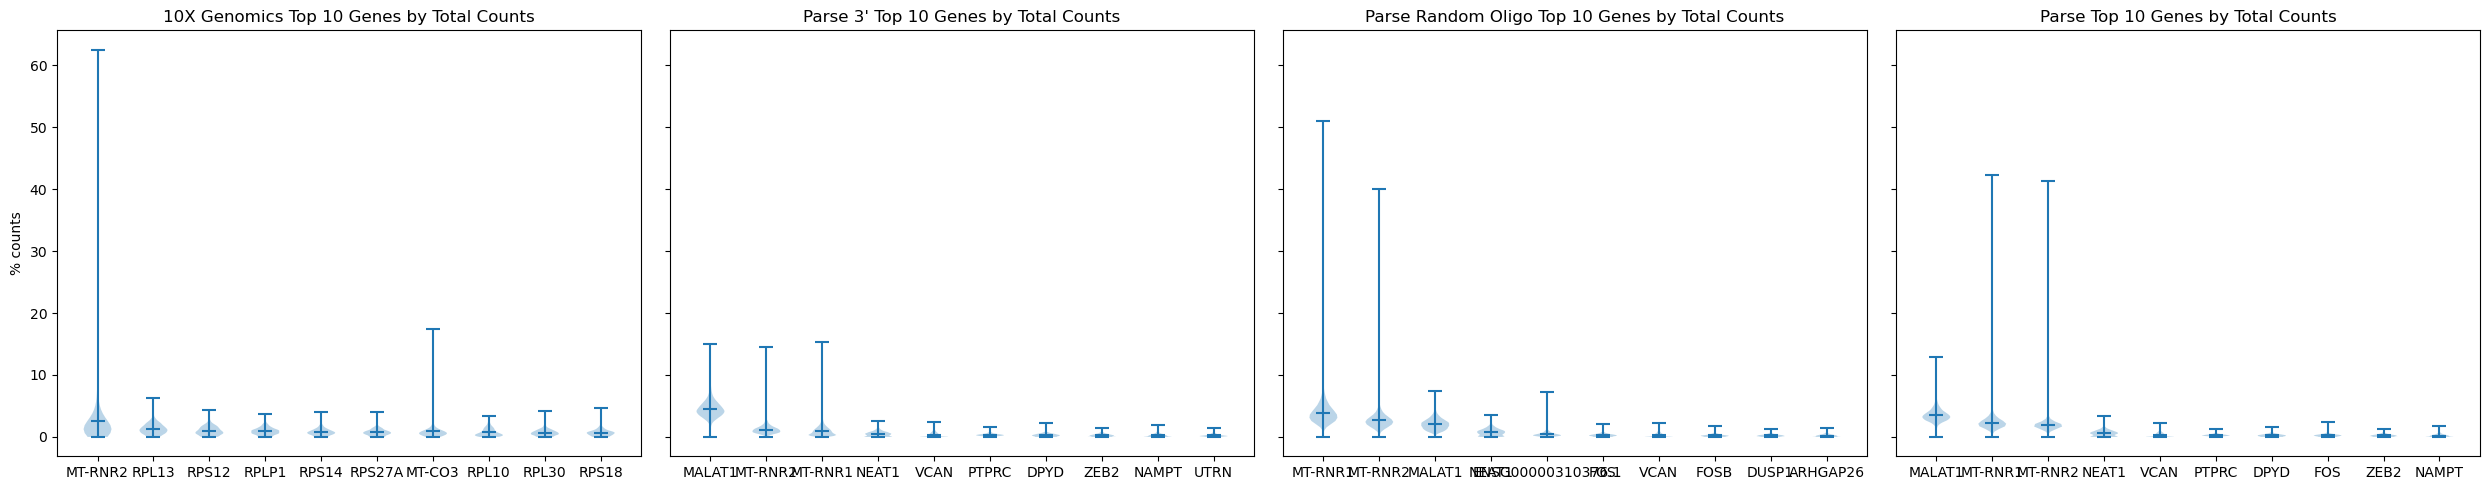

In [23]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)

for i, data in enumerate(datasets):
    plotting.top_gene_counts(ax[i], data)

ax[0].set_ylabel("% counts")

plt.tight_layout()
plt.show()

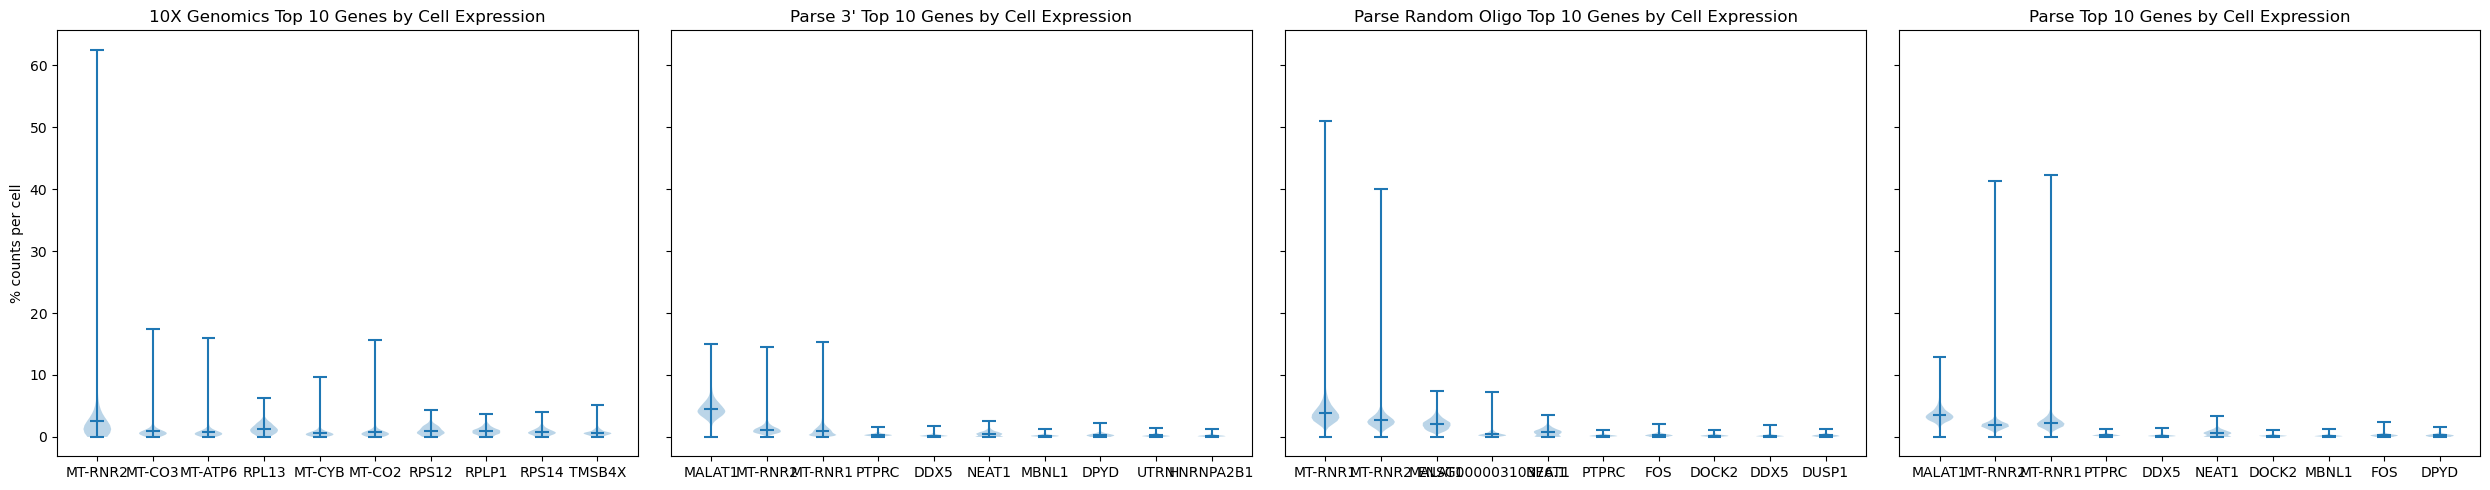

In [24]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)
for i, data in enumerate(datasets):
    plotting.top_gene_cell_expression(ax[i], data)

ax[0].set_ylabel("% counts per cell")

plt.tight_layout()
plt.show()

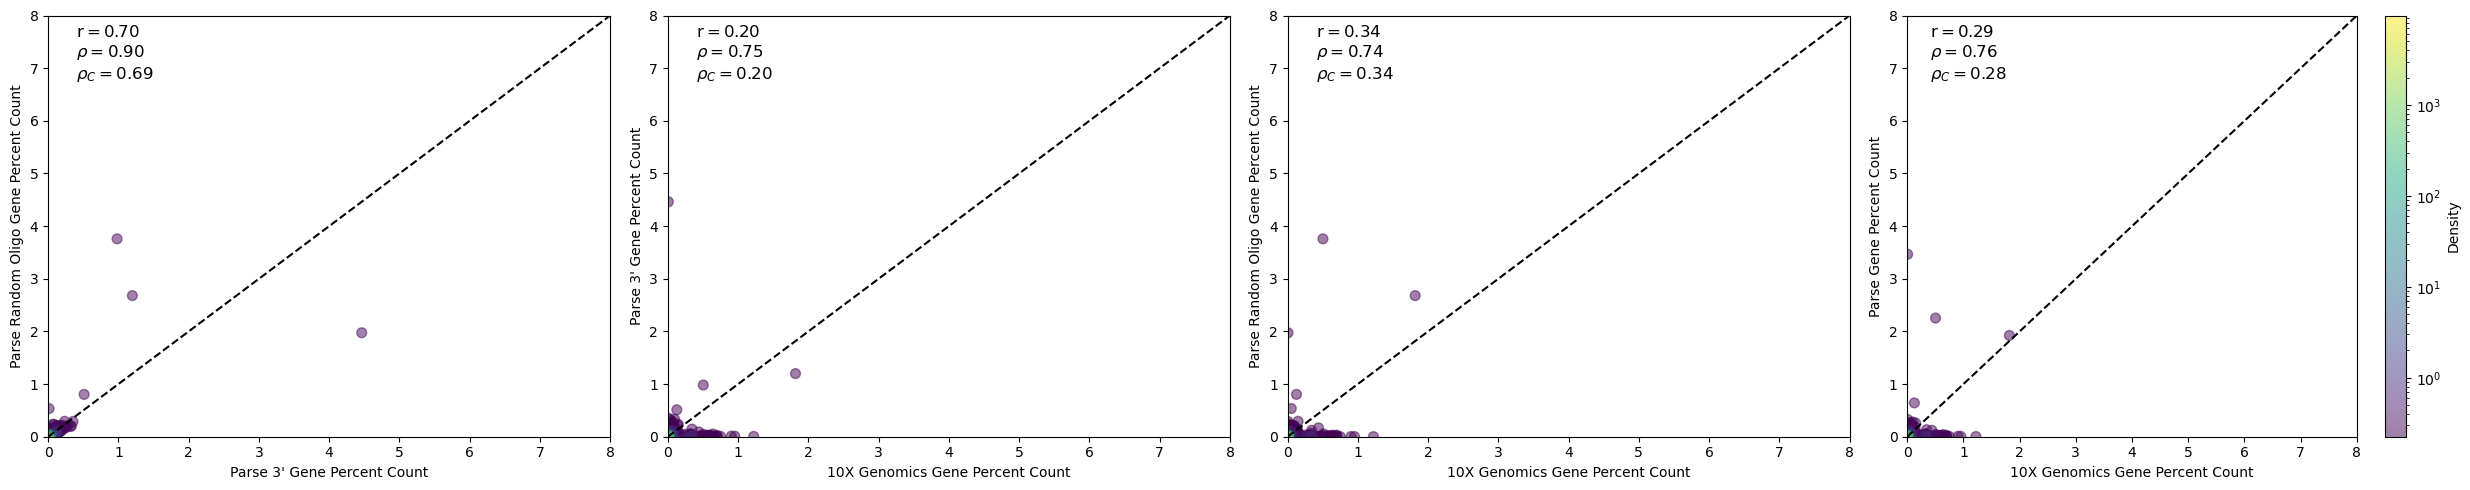

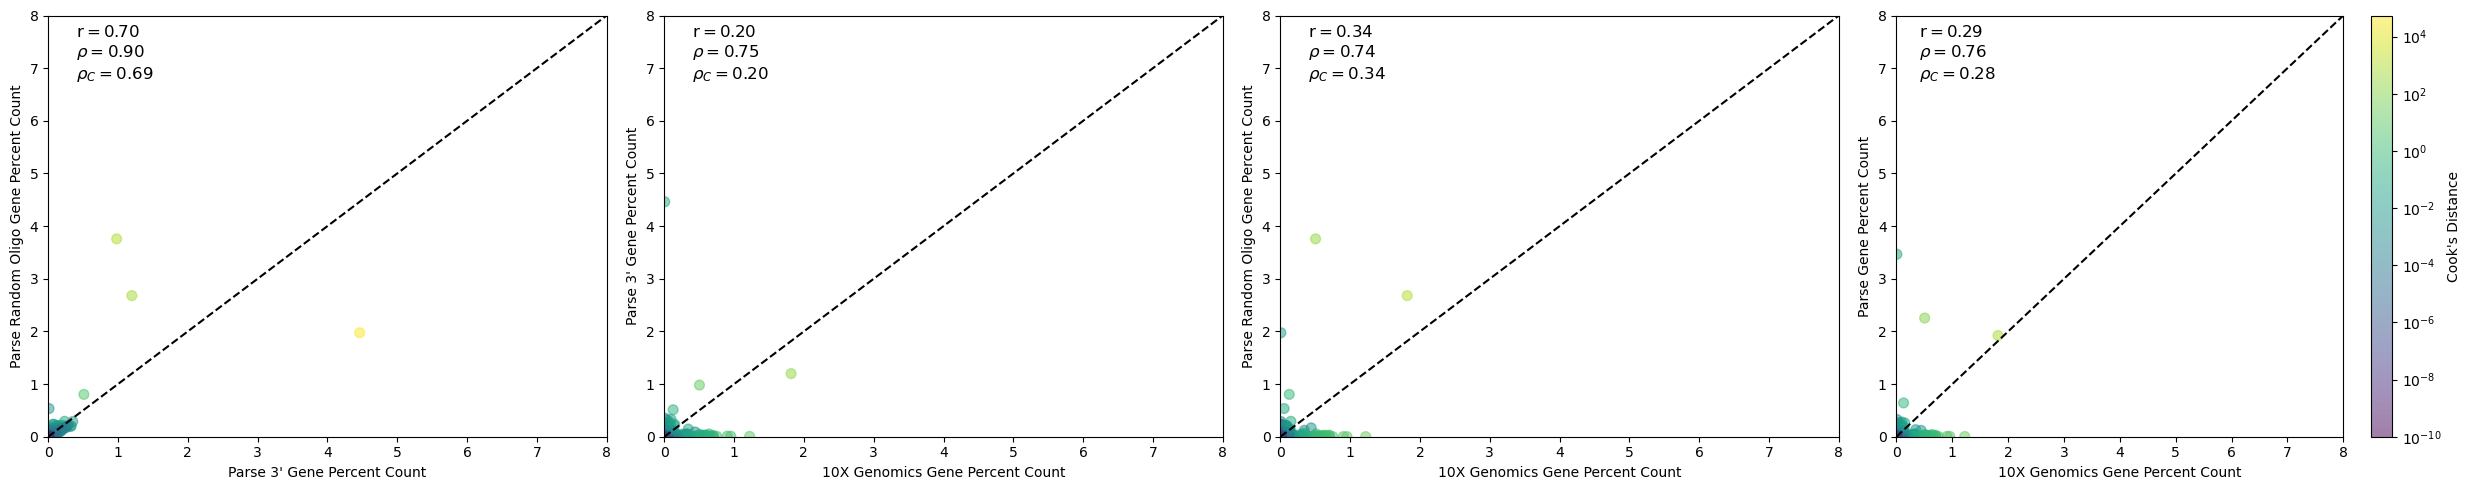

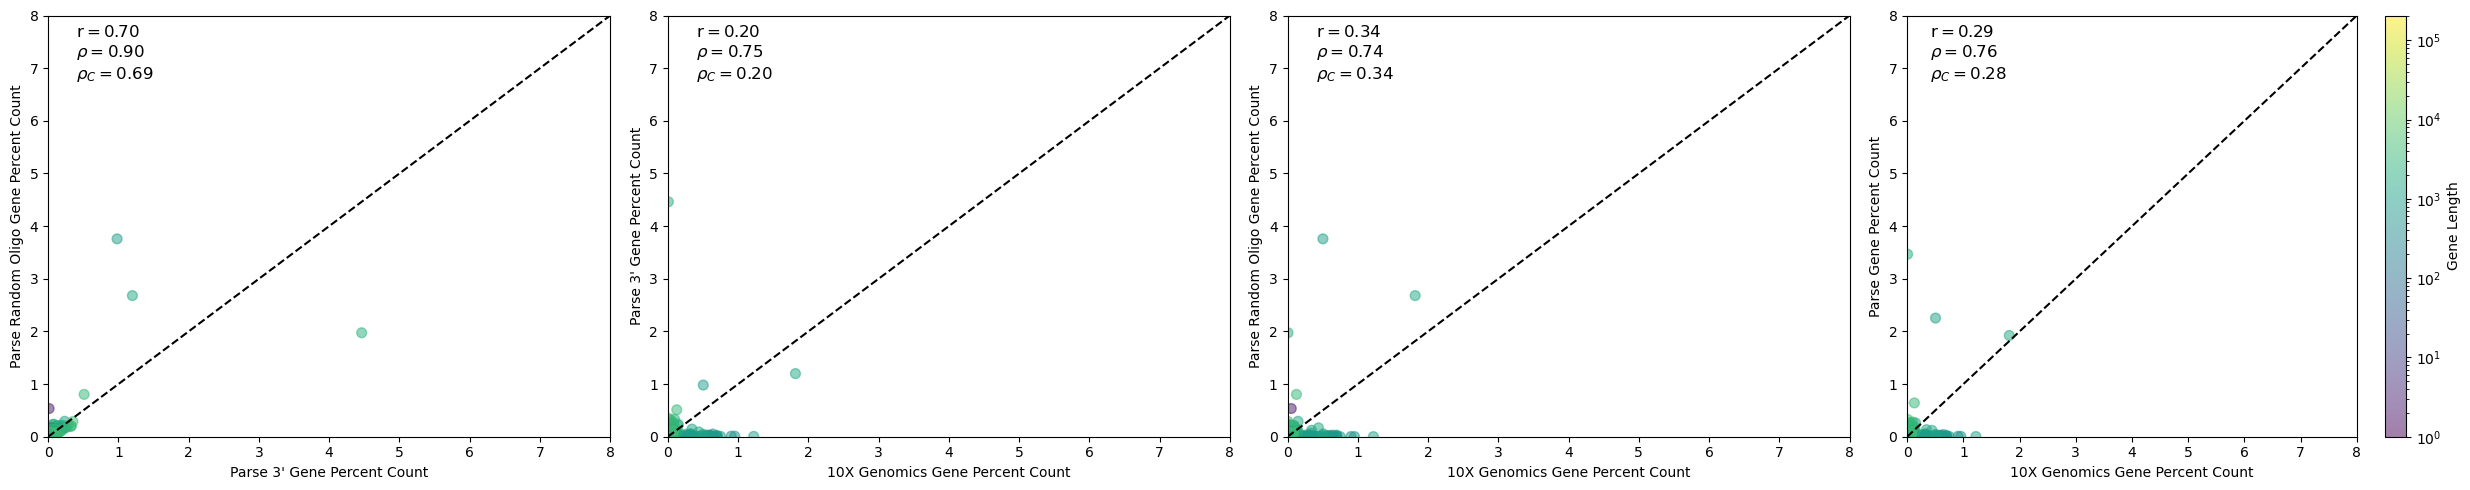

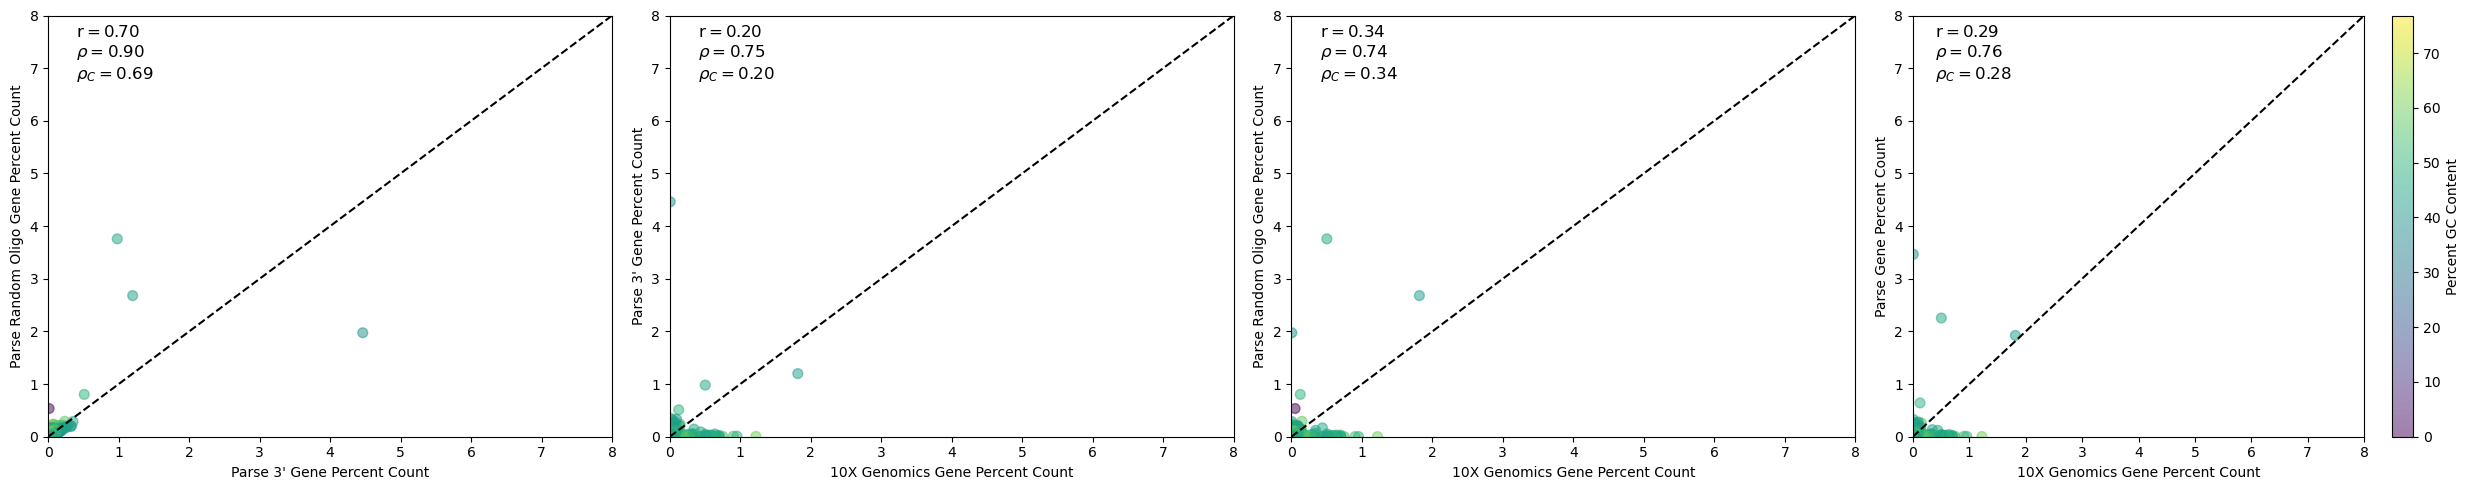

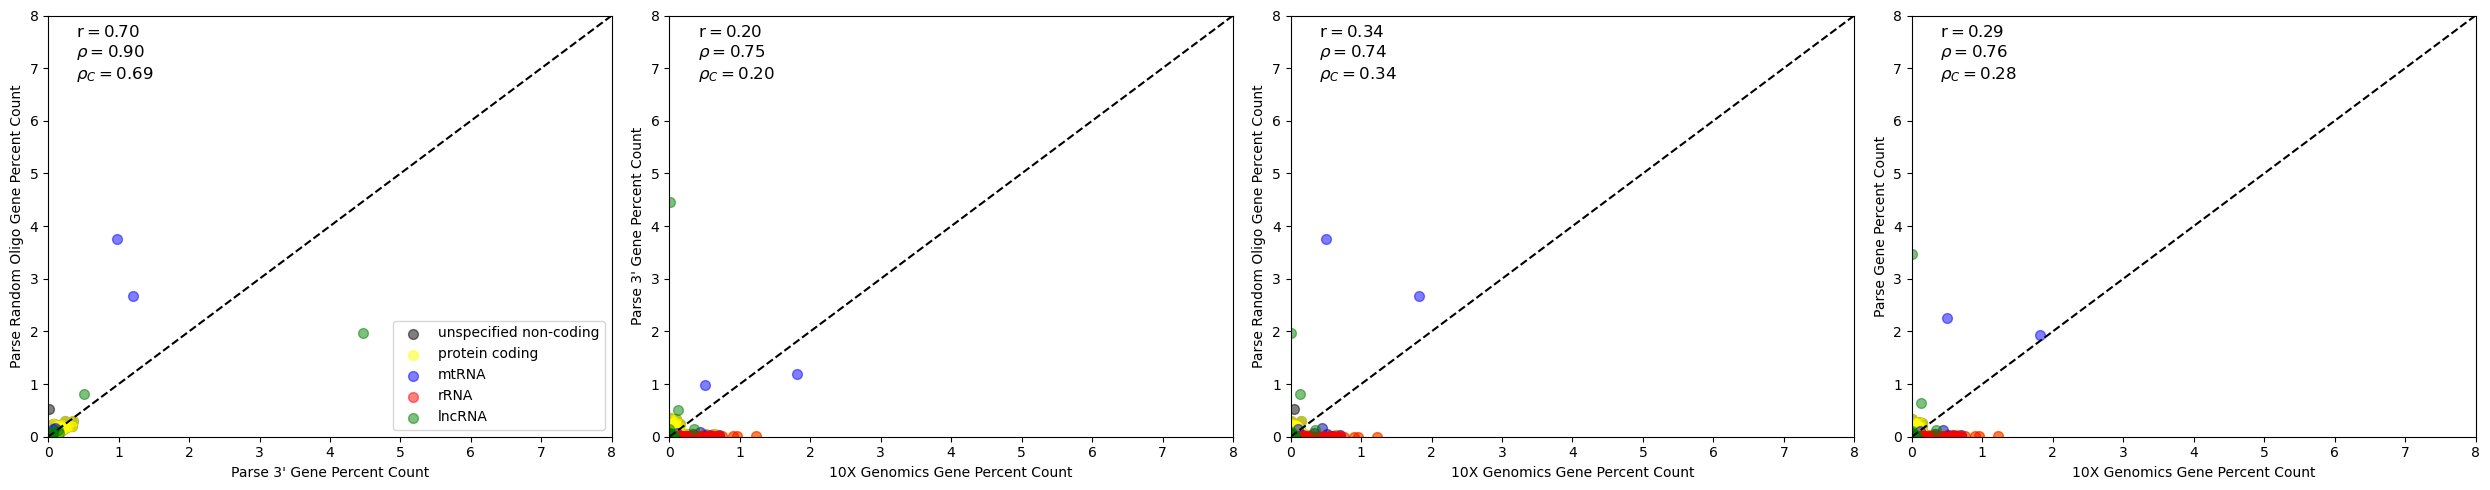

In [25]:
compare_names, compare_dfs = plotting.compare(datasets, 8)

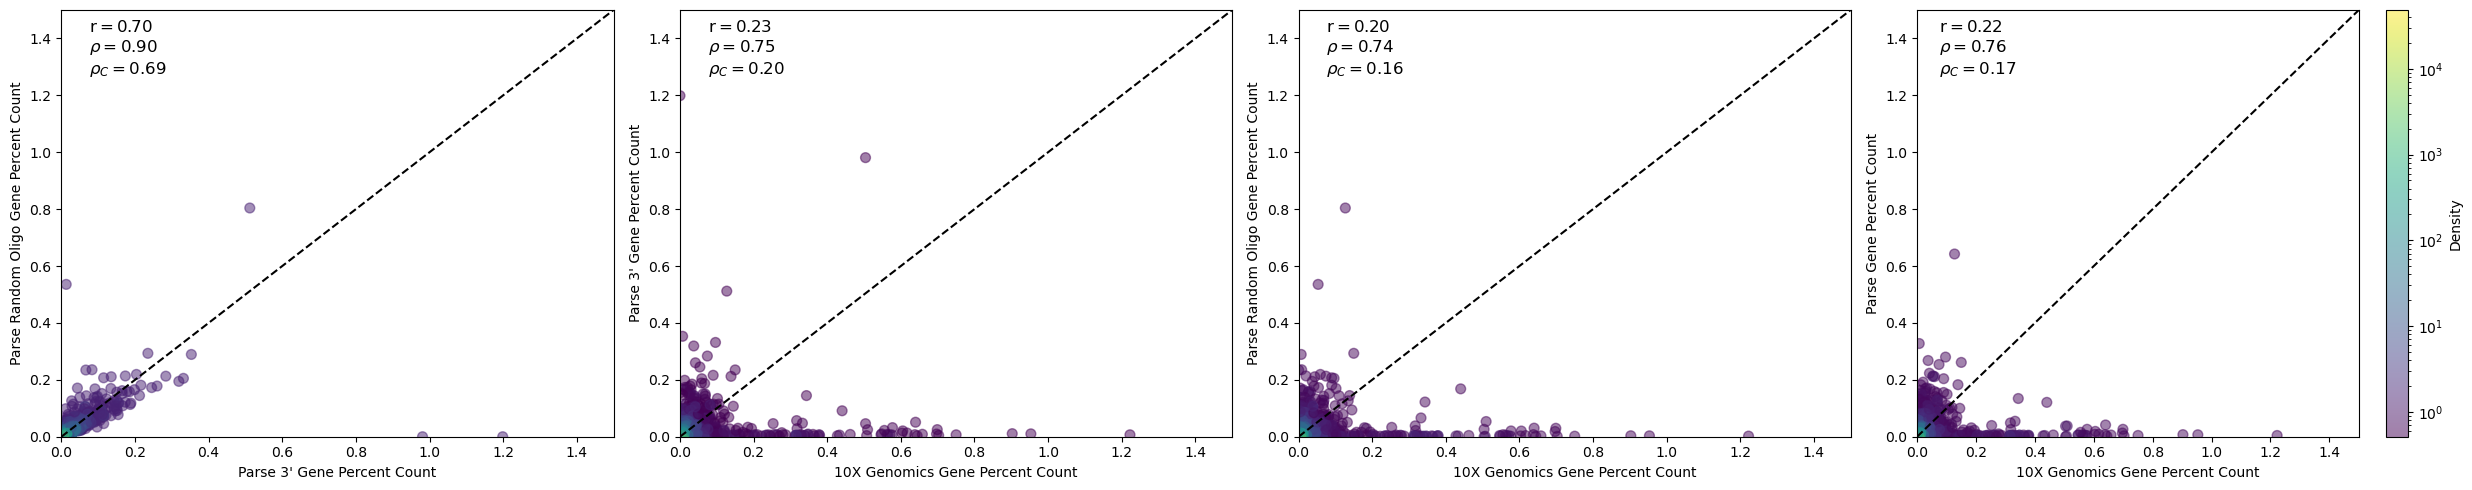

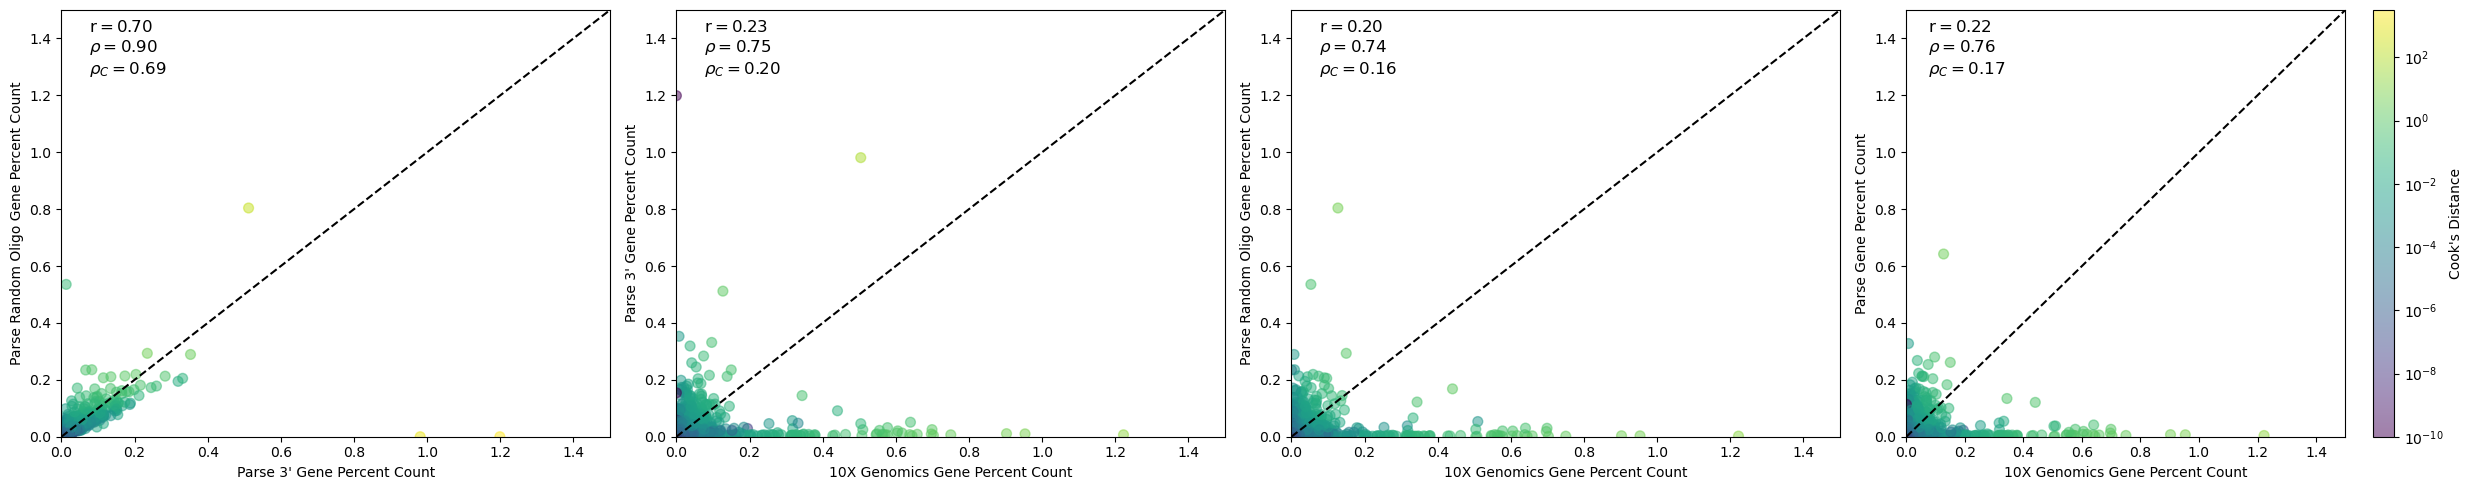

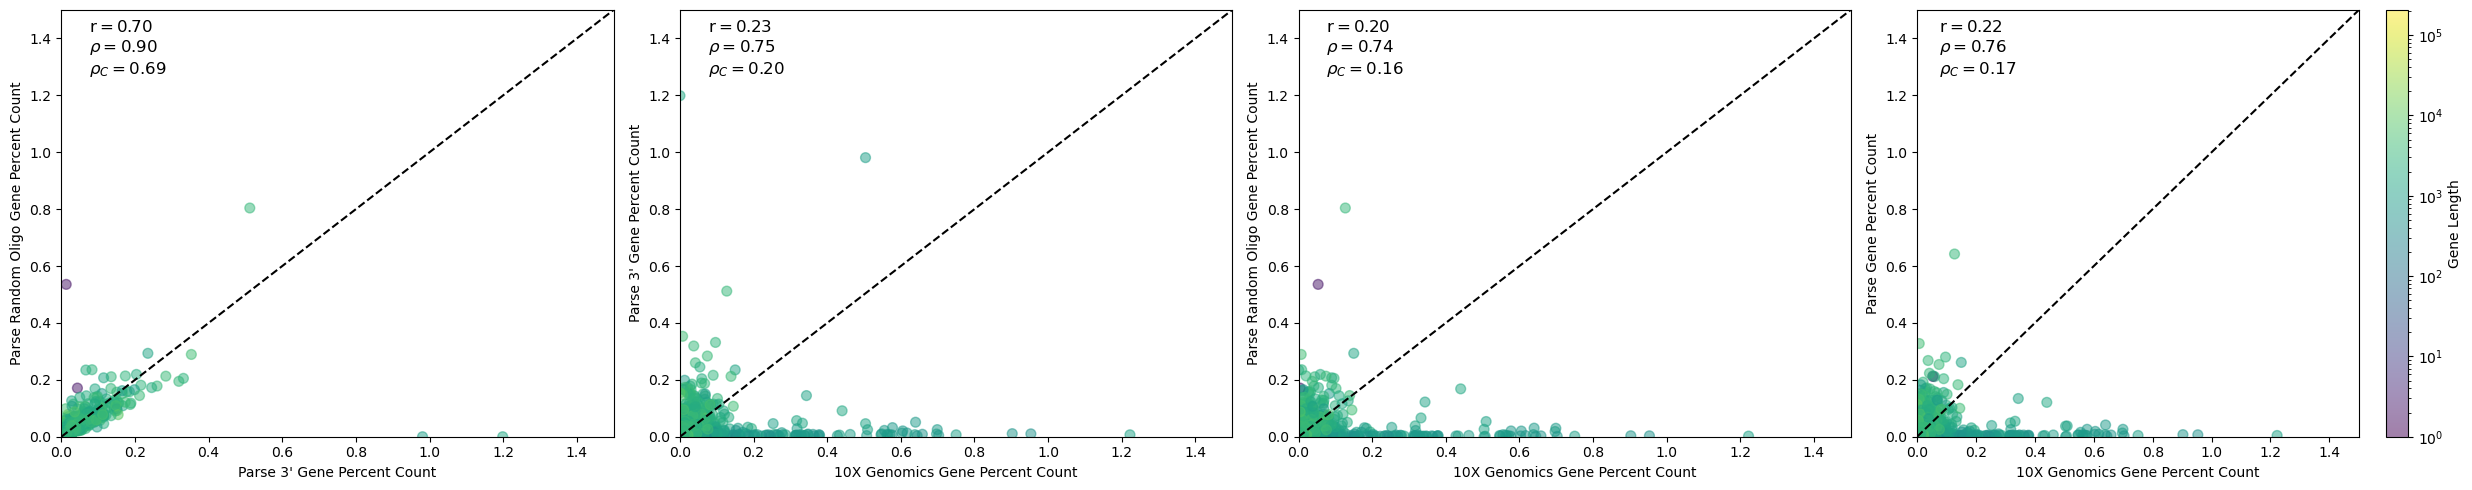

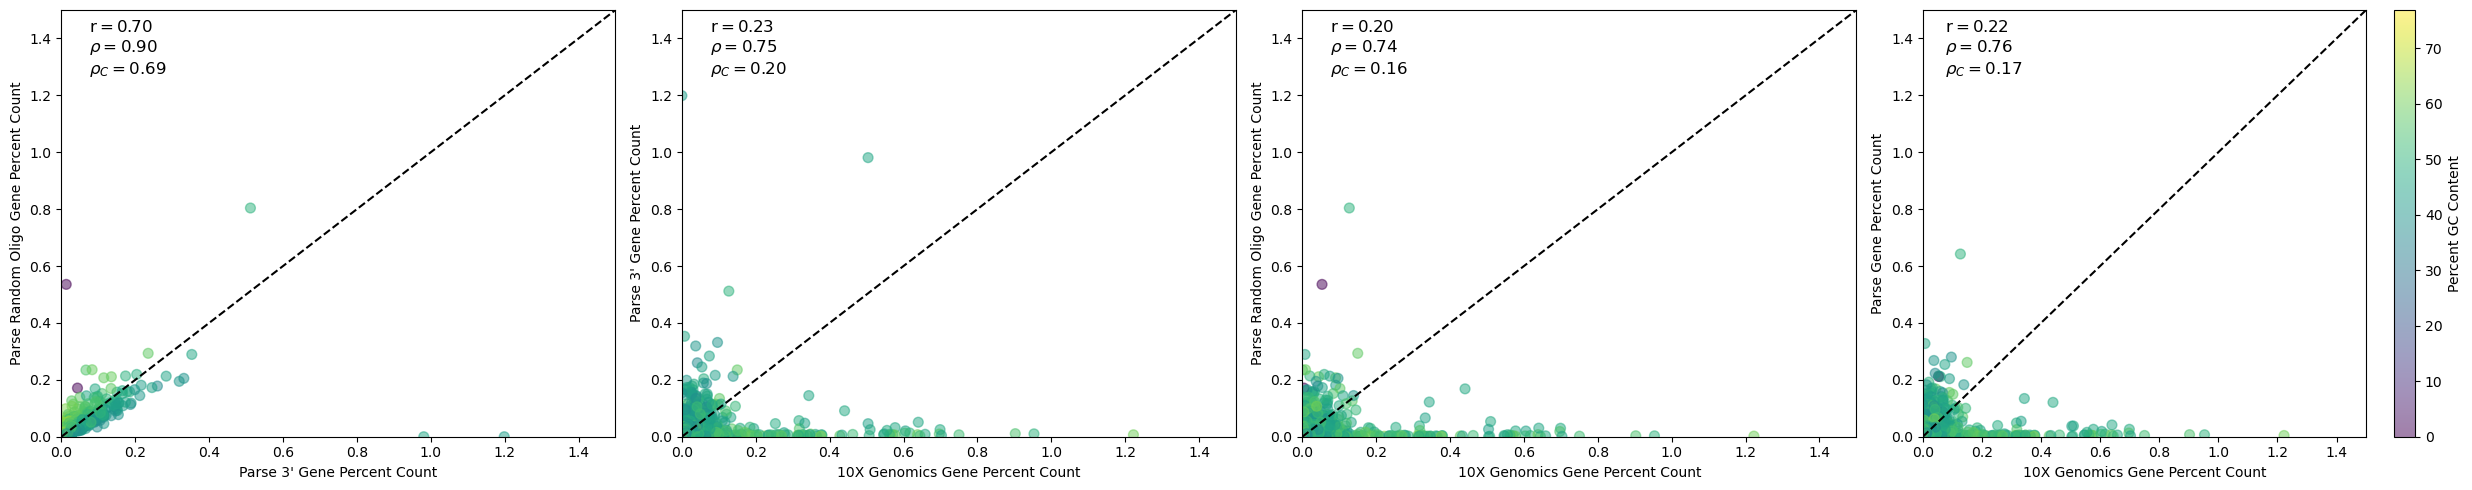

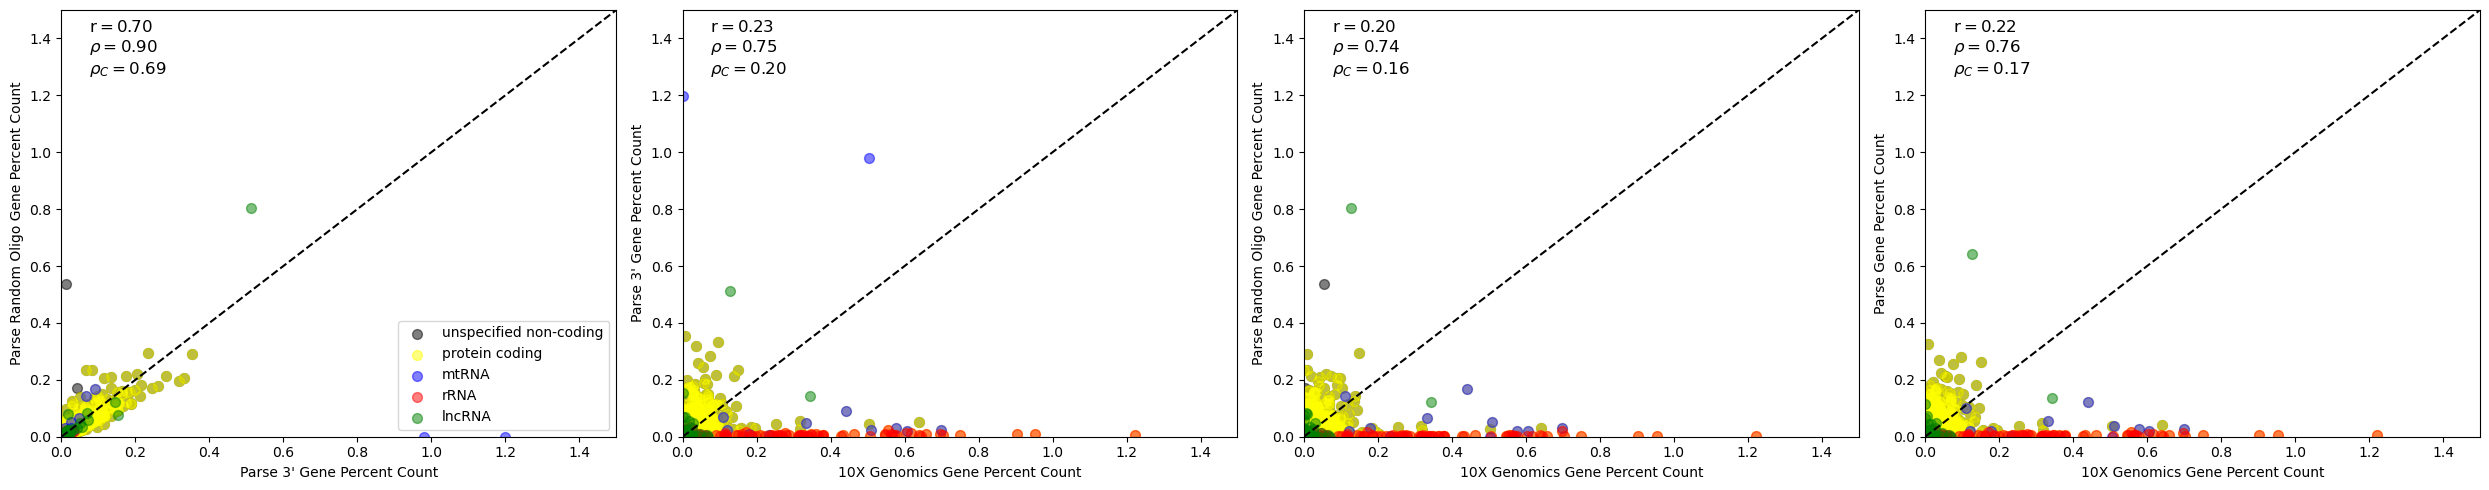

In [26]:
_, _ = plotting.compare(datasets, 1.5)

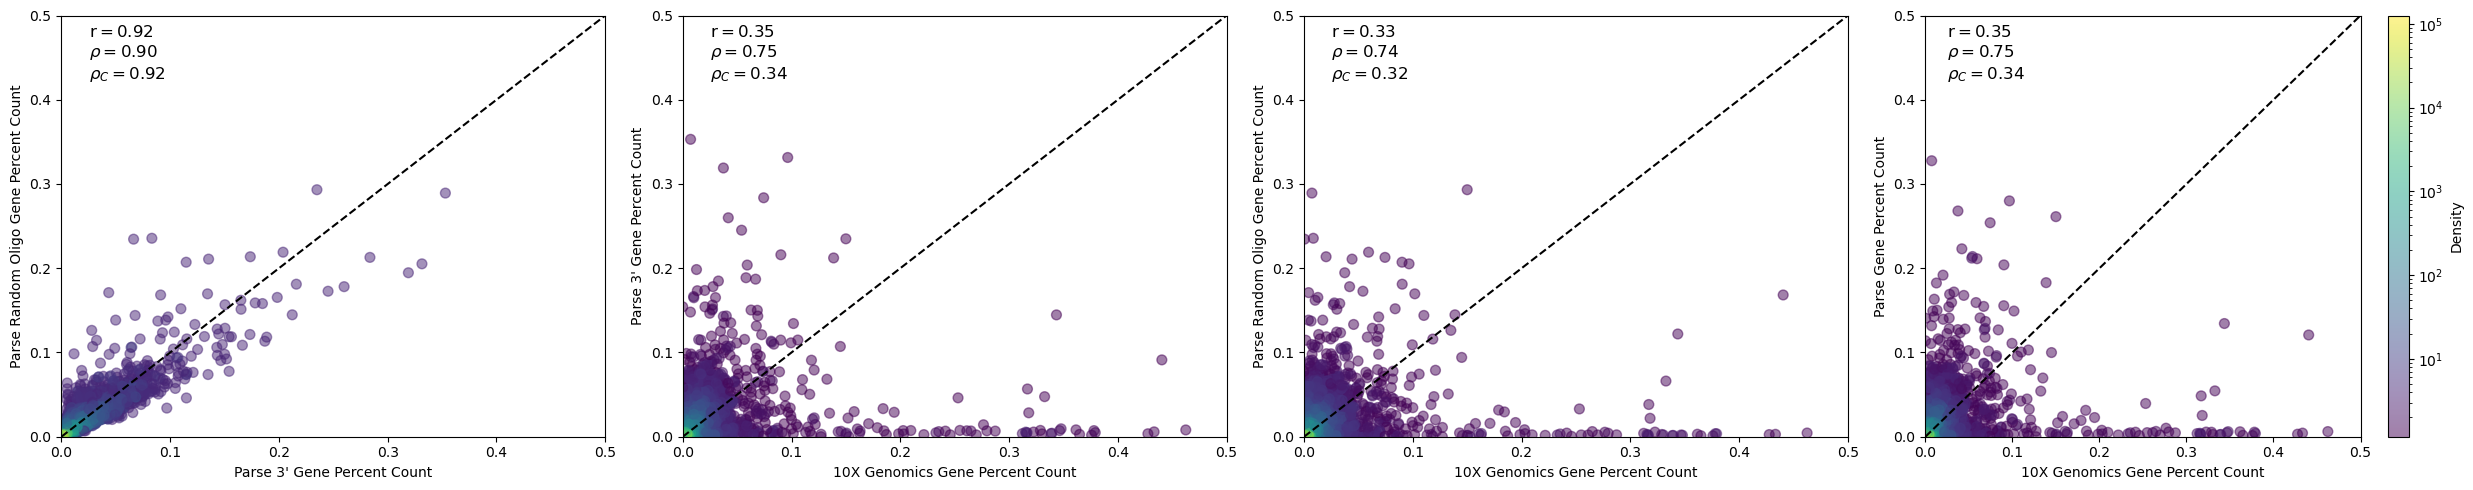

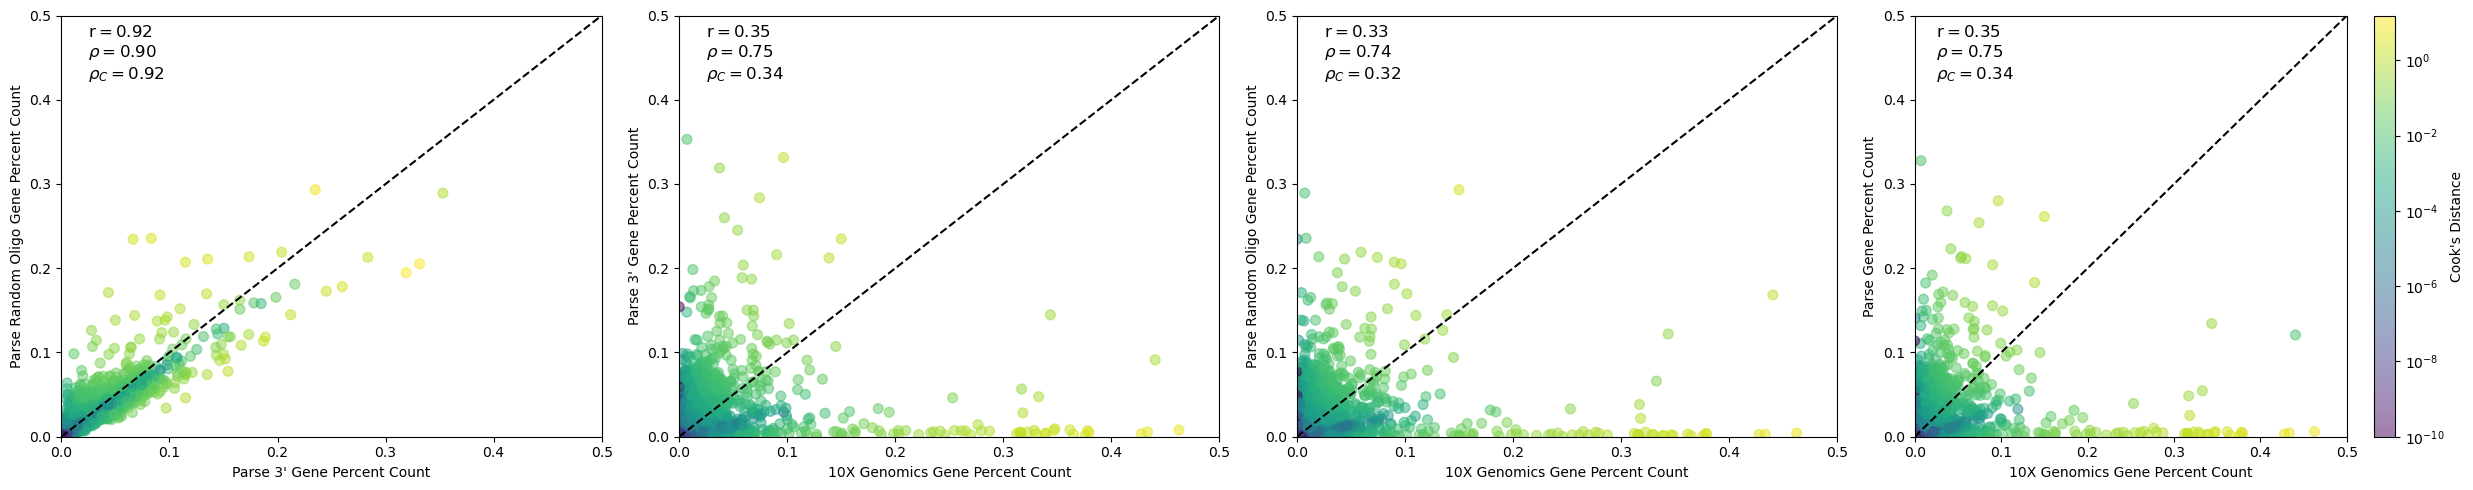

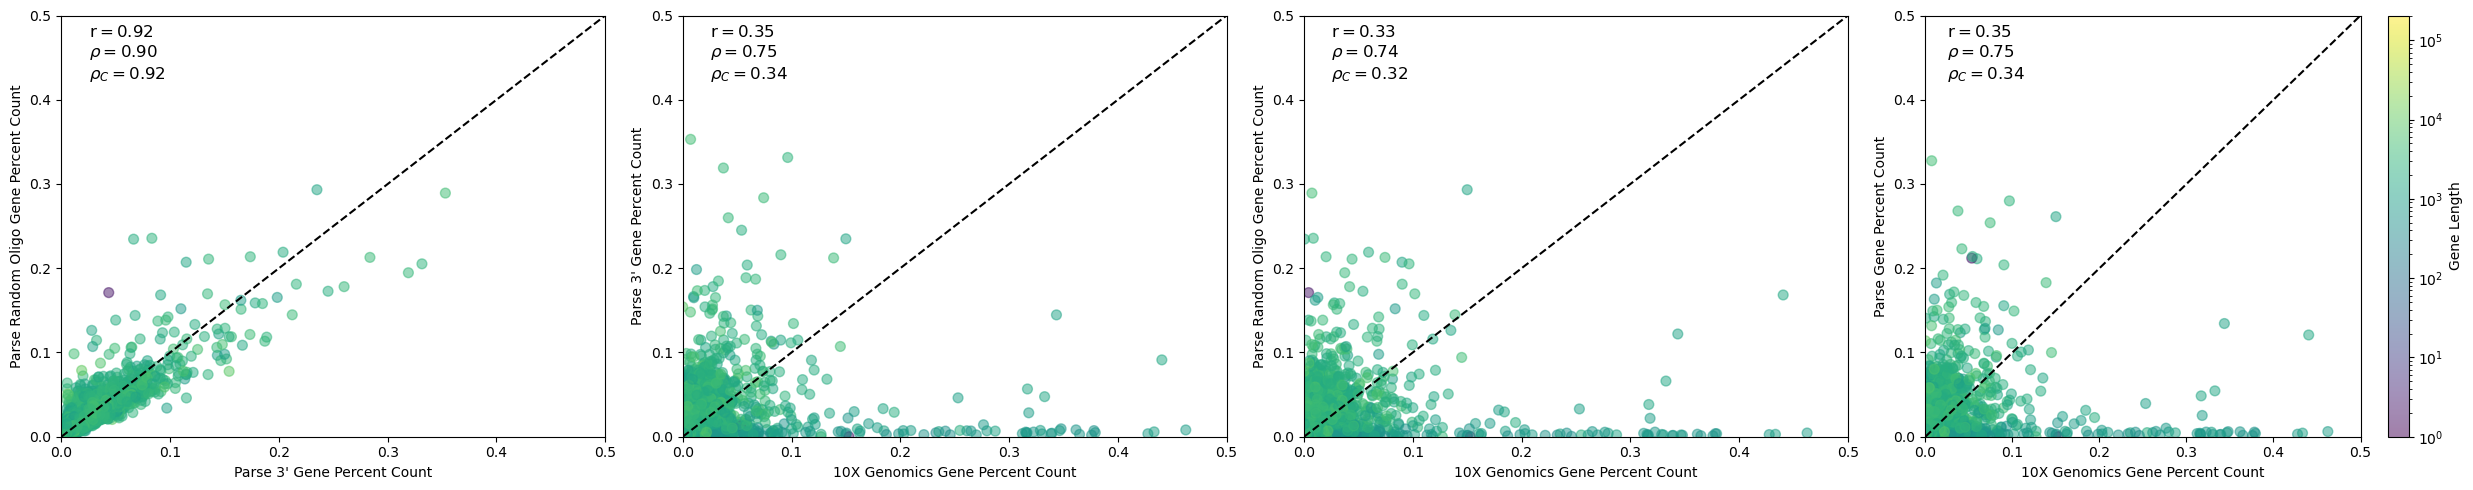

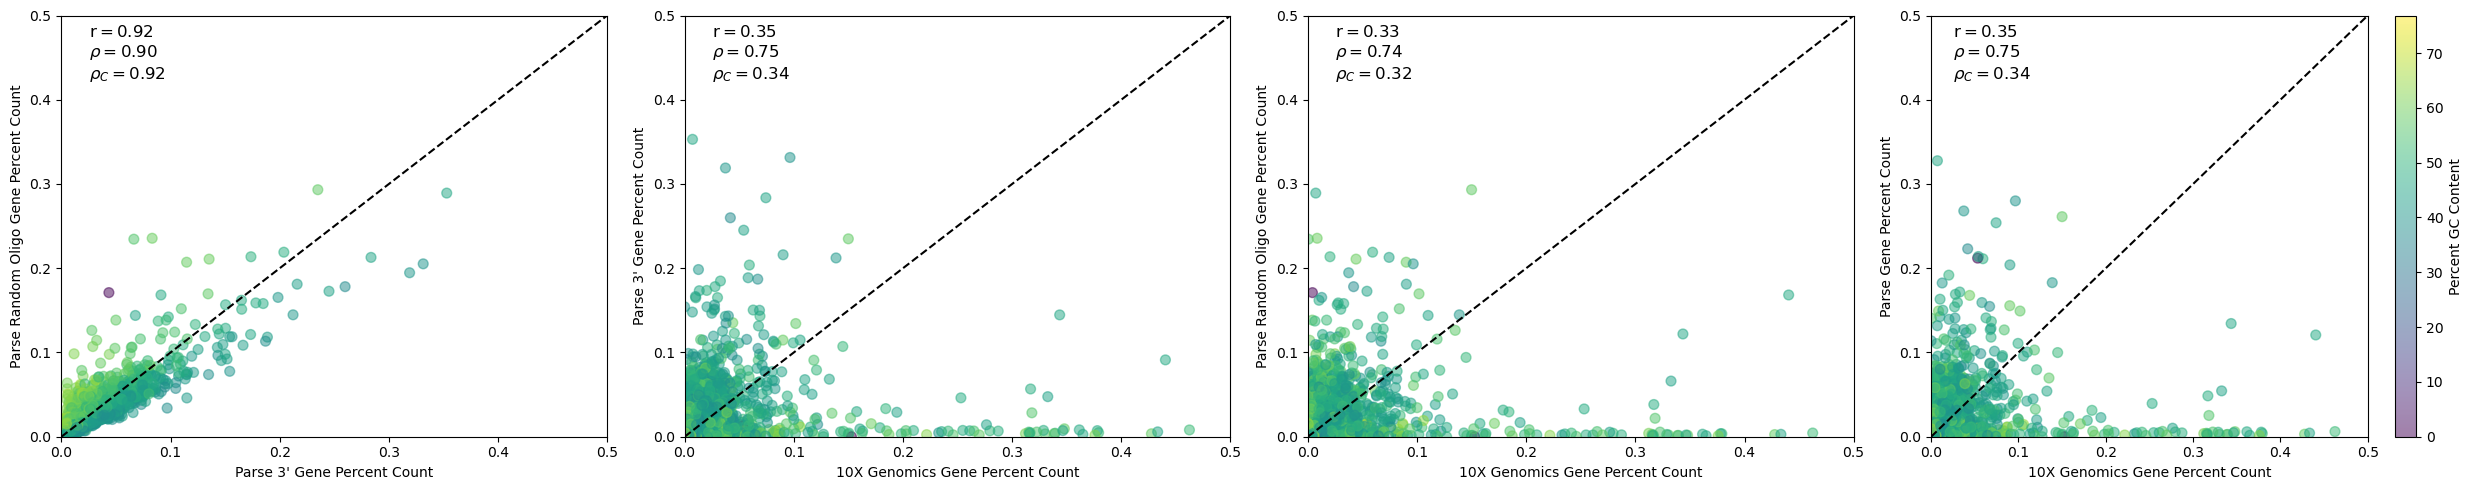

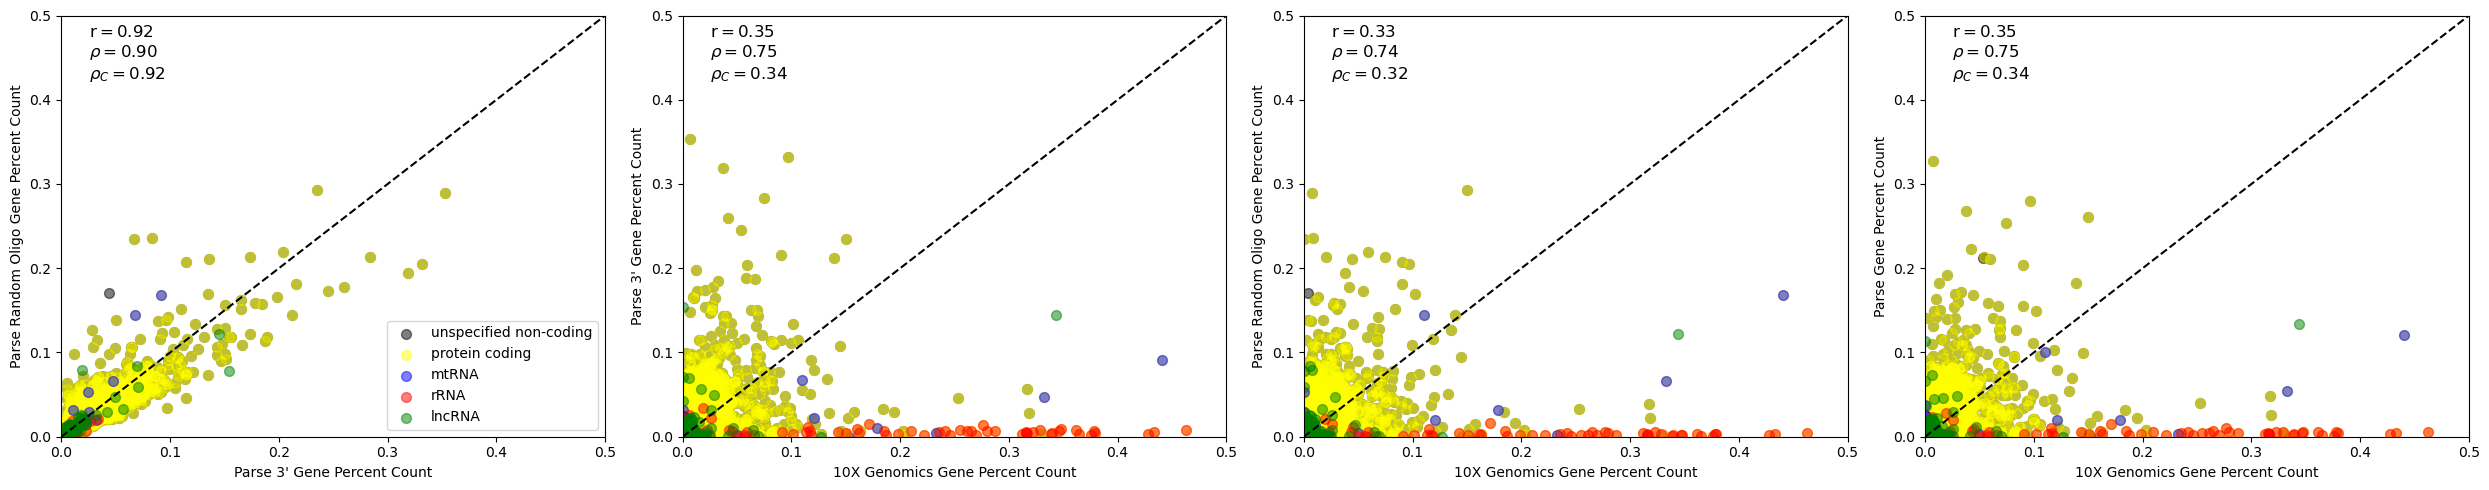

In [27]:
_, _ = plotting.compare(datasets, 0.5)

In [28]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)

full_gene_info_path = 'gene_data/gene_comparisons.csv'
gene_info.to_csv(full_gene_info_path)

In [29]:
cell_thresh = 10

contents = plotting.generate_upset(datasets, gene_info, cell_thresh)

In [30]:
# Extract gene subsets that were interesting in the upset plot

genes_10x = contents['gene_ids'][contents['10x']& 
                                 ~contents['polyT']&
                                 ~contents['randO']&
                                 ~contents['parse']]
genes_10x = genes_10x.tolist()

genes_POT = contents['gene_ids'][~contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_POT = genes_POT.tolist()

genes_PT = contents['gene_ids'][contents['10x']& 
                                ~contents['polyT']&
                                ~contents['randO']&
                                contents['parse']]
genes_PT = genes_PT.tolist()

genes_all = contents['gene_ids'][contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_all = genes_all.tolist()

set_names = ['10X', 'Parse, Parse Random Oligo, and Parse PolyT', 'Parse, and Parse PolyT', 'All Methods']
gene_sets = [genes_10x, genes_POT, genes_PT, genes_all]
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

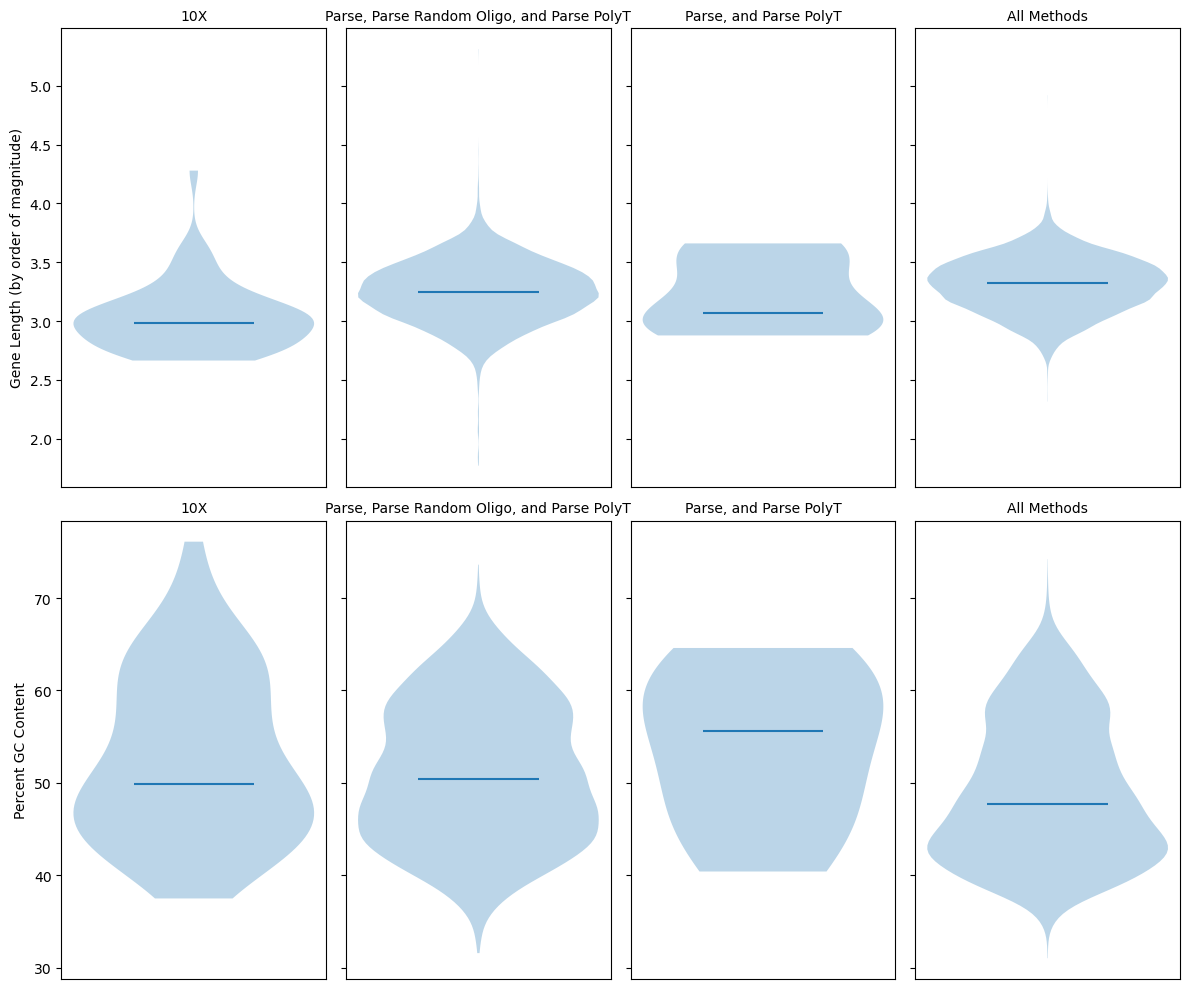

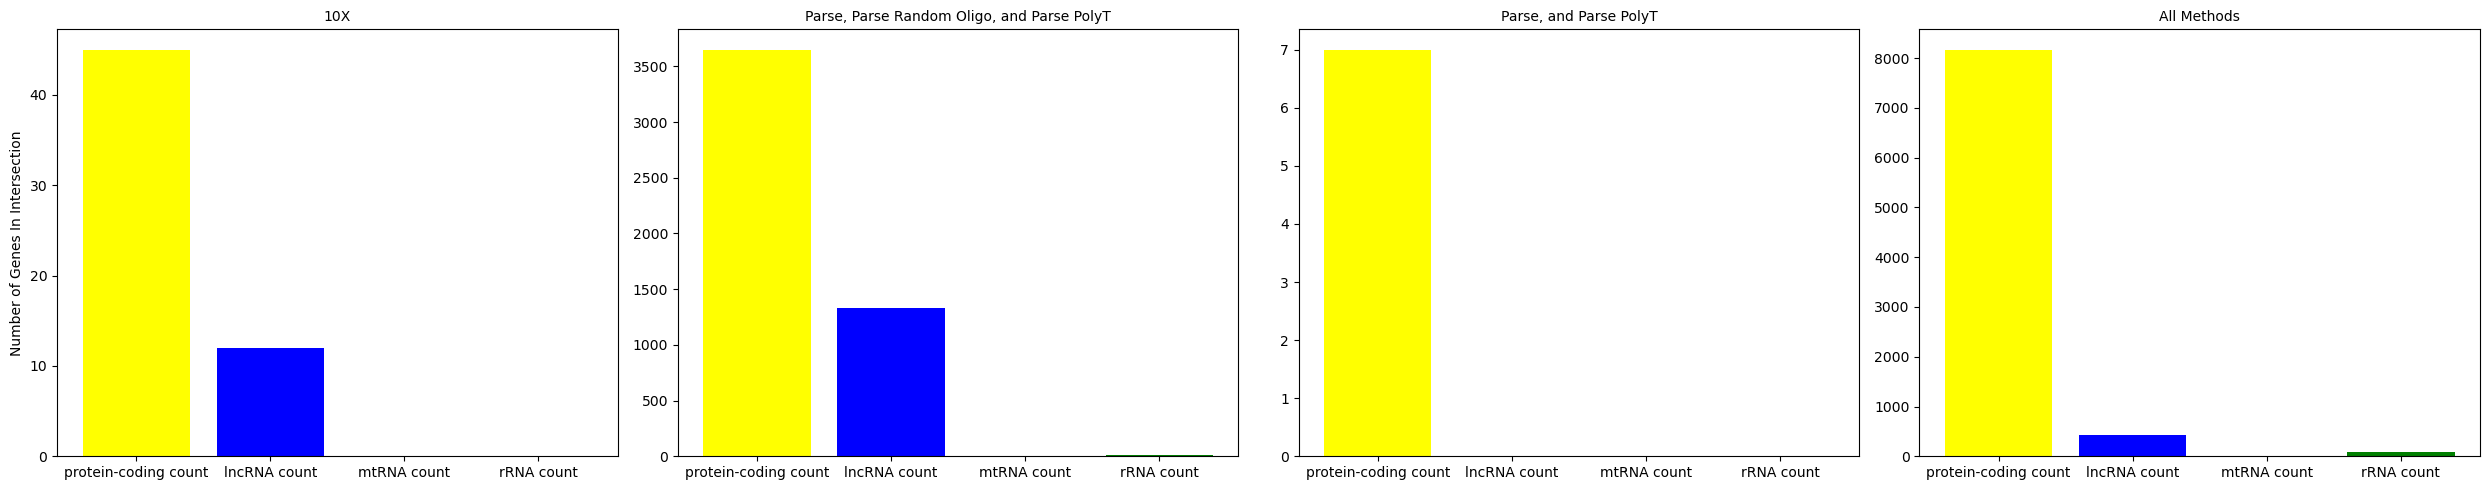

In [31]:
plotting.plot_geneset_metrics(gene_sets, set_names, gene_info)
plotting.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)

In [32]:
# Look at top 1000 genes for each method instead of all
contents = plotting.generate_upset(datasets, gene_info, cell_thresh, n_top_genes=1000)

In [33]:
genes_10x = contents['gene_ids'][contents['10x']& 
                                 ~contents['polyT']&
                                 ~contents['randO']&
                                 ~contents['parse']]
genes_10x = genes_10x.tolist()

genes_POT = contents['gene_ids'][~contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_POT = genes_POT.tolist()

genes_all = contents['gene_ids'][contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_all = genes_all.tolist()

geneset_names = ['10X', 'Parse Methods', 'All Methods']
genesets = [genes_10x, genes_POT, genes_all]
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

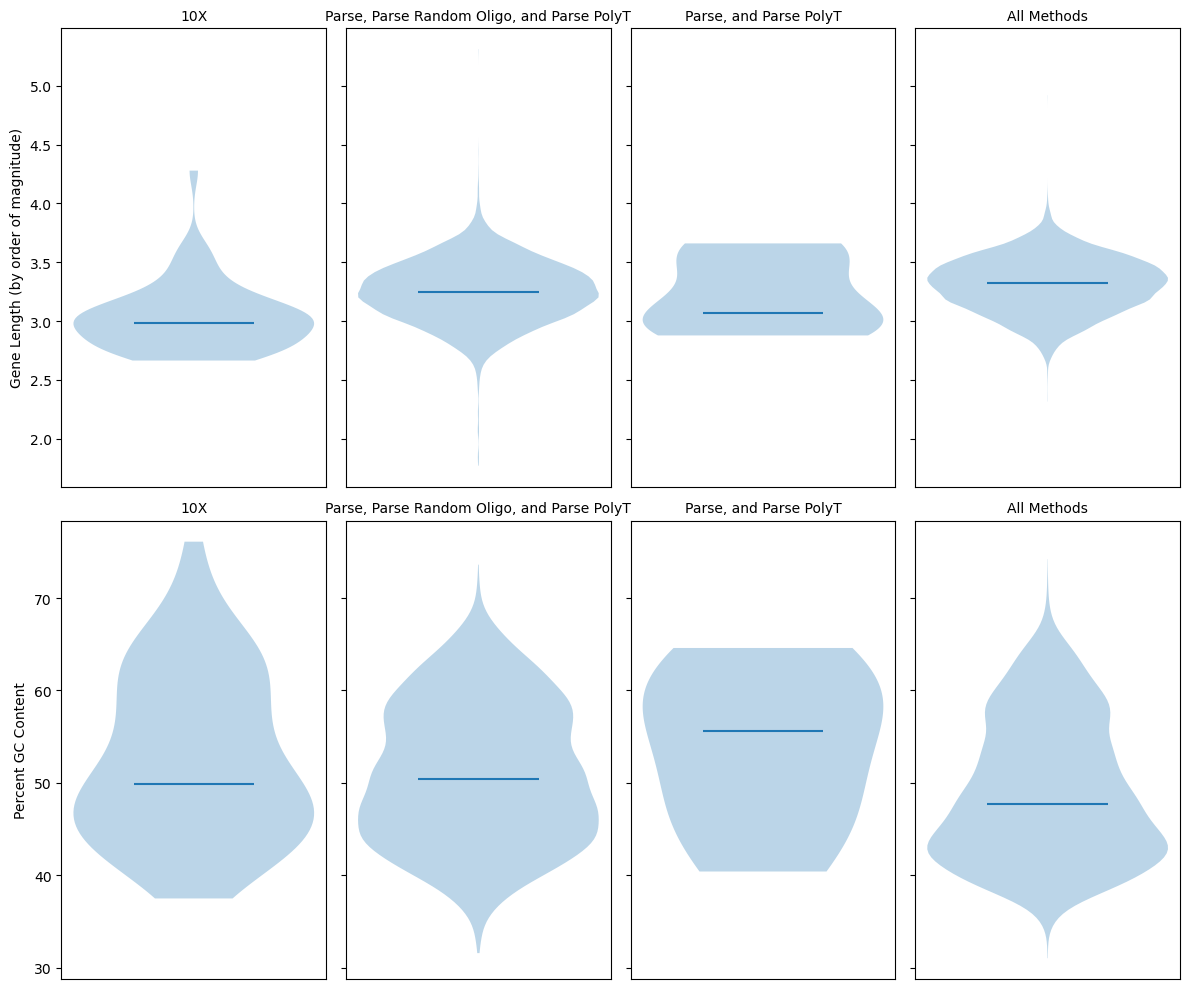

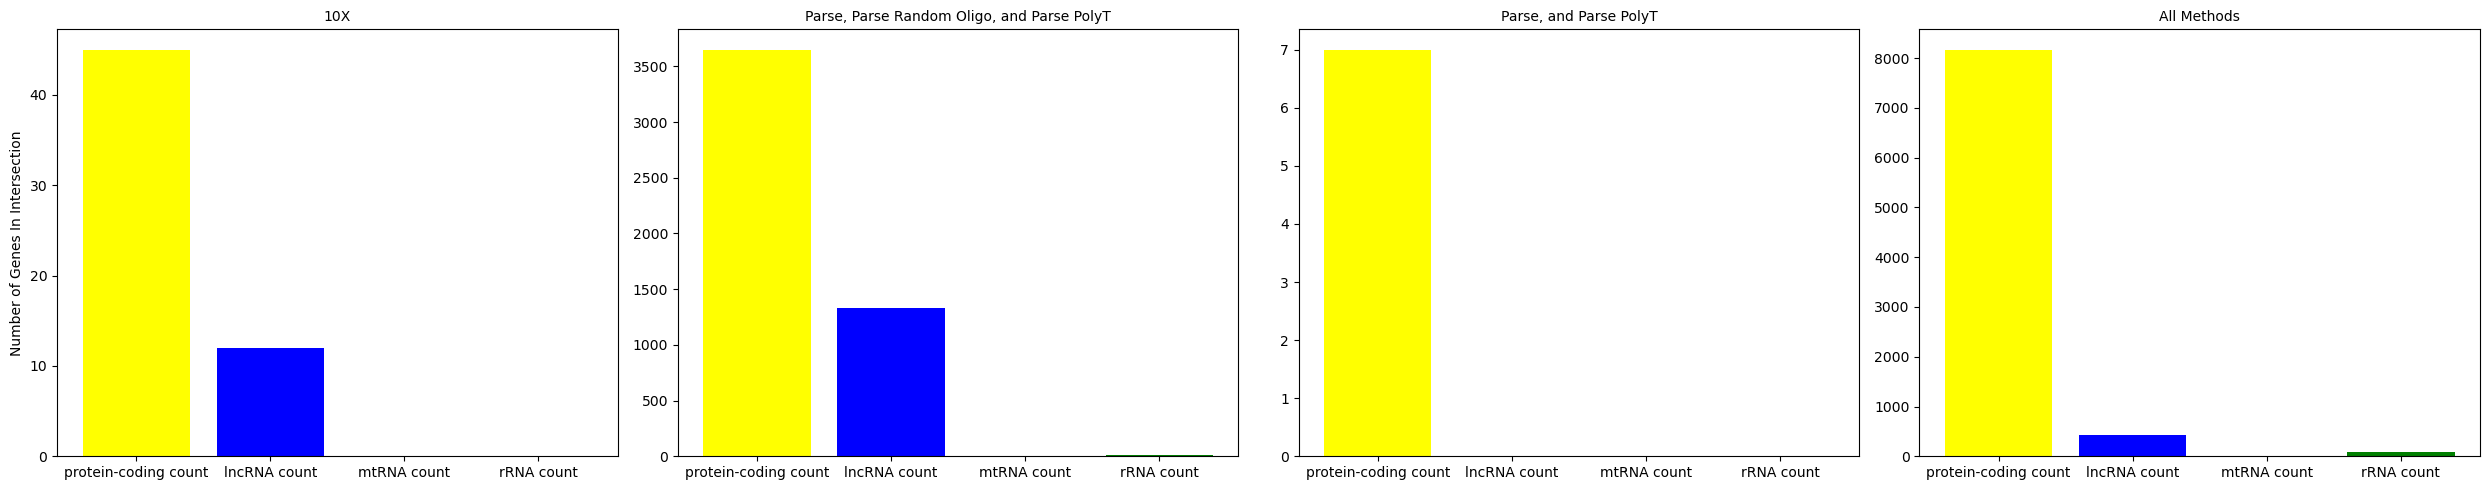

In [34]:
plotting.plot_geneset_metrics(gene_sets, set_names, gene_info)
plotting.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)